In [98]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import binomtest


from forward_price import estimate_forward_curve

from variance_risk_premium_data import (build_vrp,
                                        compounded_returns)
from Zhang_and_Xiang import (log_moneyness,
                             fit_implied_vol_curve,
                             implied_volatility_curve,
                             linear_interpolation,
                             interpolate_constant_maturity,
                             term_spreads,
                             hump_factor,
                             )
from regression_analysis import (nw_lag, 
                                 regime_indicator,
                                 in_sample_regression,
                                 r2_out_of_sample,
                                 clark_west_test,
                                 directional_accuracy,
                                 out_of_sample_test,
                                 run_full_analysis)

# Title: The Variance Risk Premium and Implied Volatility Term Structure: Regime-conditional Dynamics and Hump/Trough effect
---
By: Trevor Sakwa Timothy |
Personal email: trevorsakwa@gmail.com |
University email: sgtsakw2@liverpool.com |
Mobile: +44 7597749688 |



This paper extends Guo et a;.(2023) across a longer sample period from 2000-2025 and contributes:
* structurally distinct volatility regimes, 
* developed variance sensitive asset returns as proxies for variance risk premium - synthetic variance swaps and straddle returns
* introduces a regime-conditional framework being contango or backwardation - this tests whether the implied volatility term structures
relationship with the variance risk premium is state-dependend
* adds a hump factor that captures posible non-monotonic (non-linear) medium-term variance dynamics

## Abstract
In this study, we examine whether the shape of the S&P 500 Implied volatility term structure can predict the returns earned by investors who bear variance risk across maturities and different market regimes over the period of January 2000 to July 2025. Following the second-order polynomial Implied volatility curve parameterisation of Zhang and Xiang (2008), the implied volatility smirk is decomposed into its level, slope, and curvature factors at six constant maturities spanning 30 days to 360 days.

 We extend the work of Guo et al. (2003) and implement a regime-conditional regression framework to investigate whether the term spreads can predict the variance risk premium across contango and backwardation regimes. Additionally, we introduce a rate-normalised hump factor to capture the non-linear medium term curvature dynamics beyond end point based spreads.

Using At-the-money straddle returns and synthetic variance swap returns as model-free proxies of the variance risk premium; we find that the short-end level spread between 30 to 180 days significantly predicts the monthly straddle returns at 3 months through to 6-month maturities. The regime-conditional indicator reveals a complete sign reversal in long-end spread’s predictive slope at 12 months maturity the two regimes in the in-sample regression. The level hump factor provides supplements in-sample evidence at medium to long maturities.  Out of sample, the long-end spread between 360 day and 180-day implied volatility is the most robust predictor at the 12-month horizon, while the hump factor does not generalise beyond the estimation period. These findings suggest that structural assumptions of long run variance provide the most reliable and persistent signal for predicting the variance risk premium


requirements: 
* dissertation_data.csv


see: sourcing.ipynb for explanation

cleaning summary
initial rows: 47374551
 after IV filter: removed:  4946157 rows
 after maturity filter: removed: 2614909 rows
 after best bid filter : removed 1677566 rows
 after midprice filter: removed 785252
 after strike price filter: removed 9953082 rows
after zero OI/volume filter: removed 567 rows
final test rows: 27397585

info: 
<class 'pandas.DataFrame'>
Index: 27397018 entries, 0 to 47374547
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[us]
 1   exdate           datetime64[us]
 2   cp_flag          str           
 3   strike_price     float64       
 4   best_bid         float64       
 5   best_offer       float64       
 6   volume           int64         
 7   open_interest    int64         
 8   impl_volatility  float64       
 9   optionid         int64         
 10  am_settlement    int64         
 11  expiry           int64         
 12  mid_price        float64       
dtypes: datetime64[us](2), float64(5), int64(5), str(1)
memory usage: 2.9 GB

use: cleaned_research_data.csv

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>date</th>
      <th>exdate</th>
      <th>cp_flag</th>
      <th>strike_price</th>
      <th>best_bid</th>
      <th>best_offer</th>
      <th>volume</th>
      <th>open_interest</th>
      <th>impl_volatility</th>
      <th>optionid</th>
      <th>am_settlement</th>
      <th>expiry</th>
      <th>mid_price</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>2000-01-03</td>
      <td>2000-01-22</td>
      <td>P</td>
      <td>1505.0</td>
      <td>55.25</td>
      <td>57.25</td>
      <td>0</td>
      <td>50</td>
      <td>0.213004</td>
      <td>10000760</td>
      <td>1</td>
      <td>18</td>
      <td>56.250</td>
    </tr>
    <tr>
      <th>3</th>
      <td>2000-01-03</td>
      <td>2000-09-16</td>
      <td>C</td>
      <td>1450.0</td>
      <td>135.75</td>
      <td>137.75</td>
      <td>0</td>
      <td>2365</td>
      <td>0.221215</td>
      <td>10011763</td>
      <td>1</td>
      <td>256</td>
      <td>136.750</td>
    </tr>
    <tr>
      <th>4</th>
      <td>2000-01-03</td>
      <td>2000-06-17</td>
      <td>P</td>
      <td>1350.0</td>
      <td>40.75</td>
      <td>42.75</td>
      <td>290</td>
      <td>14570</td>
      <td>0.257464</td>
      <td>10016917</td>
      <td>1</td>
      <td>165</td>
      <td>41.750</td>
    </tr>
    <tr>
      <th>5</th>
      <td>2000-01-03</td>
      <td>2000-06-17</td>
      <td>P</td>
      <td>1275.0</td>
      <td>27.25</td>
      <td>29.25</td>
      <td>0</td>
      <td>5513</td>
      <td>0.279201</td>
      <td>10024738</td>
      <td>1</td>
      <td>165</td>
      <td>28.250</td>
    </tr>
    <tr>
      <th>6</th>
      <td>2000-01-03</td>
      <td>2000-03-18</td>
      <td>C</td>
      <td>1575.0</td>
      <td>13.50</td>
      <td>14.75</td>
      <td>43</td>
      <td>619</td>
      <td>0.184711</td>
      <td>10029228</td>
      <td>1</td>
      <td>74</td>
      <td>14.125</td>
    </tr>
    <tr>
      <th>...</th>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
    </tr>
    <tr>
      <th>47374526</th>
      <td>2025-07-31</td>
      <td>2026-06-30</td>
      <td>P</td>
      <td>6675.0</td>
      <td>422.40</td>
      <td>424.40</td>
      <td>0</td>
      <td>10</td>
      <td>0.145942</td>
      <td>170692343</td>
      <td>0</td>
      <td>334</td>
      <td>423.400</td>
    </tr>
    <tr>
      <th>47374527</th>
      <td>2025-07-31</td>
      <td>2026-06-30</td>
      <td>P</td>
      <td>6700.0</td>
      <td>433.00</td>
      <td>435.00</td>
      <td>0</td>
      <td>236</td>
      <td>0.144422</td>
      <td>170136862</td>
      <td>0</td>
      <td>334</td>
      <td>434.000</td>
    </tr>
    <tr>
      <th>47374528</th>
      <td>2025-07-31</td>
      <td>2026-06-30</td>
      <td>P</td>
      <td>6725.0</td>
      <td>444.40</td>
      <td>446.40</td>
      <td>0</td>
      <td>1</td>
      <td>0.143124</td>
      <td>170692344</td>
      <td>0</td>
      <td>334</td>
      <td>445.400</td>
    </tr>
    <tr>
      <th>47374529</th>
      <td>2025-07-31</td>
      <td>2026-06-30</td>
      <td>P</td>
      <td>6750.0</td>
      <td>455.70</td>
      <td>457.90</td>
      <td>0</td>
      <td>20</td>
      <td>0.141709</td>
      <td>170136863</td>
      <td>0</td>
      <td>334</td>
      <td>456.800</td>
    </tr>
    <tr>
      <th>47374530</th>
      <td>2025-07-31</td>
      <td>2026-06-30</td>
      <td>P</td>
      <td>6775.0</td>
      <td>467.80</td>
      <td>469.60</td>
      <td>0</td>
      <td>1</td>
      <td>0.140388</td>
      <td>170692345</td>
      <td>0</td>
      <td>334</td>
      <td>468.700</td>
    </tr>
  </tbody>
</table>
<p>27397008 rows × 13 columns</p>
</div>



## sourcing data

In [16]:
data = pd.read_csv("cleaned_research_data.csv")

In [129]:
data.head()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,optionid,am_settlement,expiry,mid_price
0,2000-01-03,2000-01-22,P,1505.0,55.25,57.25,0,50,0.213004,10000760,1,18,56.250
1,2000-01-03,2000-09-16,C,1450.0,135.75,137.75,0,2365,0.221215,10011763,1,256,136.750
2,2000-01-03,2000-06-17,P,1350.0,40.75,42.75,290,14570,0.257464,10016917,1,165,41.750
3,2000-01-03,2000-06-17,P,1275.0,27.25,29.25,0,5513,0.279201,10024738,1,165,28.250
4,2000-01-03,2000-03-18,C,1575.0,13.50,14.75,43,619,0.184711,10029228,1,74,14.125


In [18]:
vix_series = pd.read_csv("vix-2000-2025-prepped.csv")
vix_series.head()

,date,vix
0,2000-01-03,24.21
1,2000-01-04,27.01
2,2000-01-05,26.41
3,2000-01-06,25.73
4,2000-01-07,21.72


In [19]:
print(f"option rows      :  {len(data):,}")
print(f"option data range:  {data["date"].min()} to {data["date"].max()}")
print(f"vix rows         :  {len(vix_series)}")
print(f"vix nan count    :{vix_series.isna().sum()}" )

option rows      :  27,397,018
option data range:  2000-01-03 to 2025-07-31
vix rows         :  6529
vix nan count    :date    0
vix     0
dtype: int64


### sourcing forward data as forward_df

applies estimate_forward_curve from forward_price.py

return: Dataframe

csv: forward_price_data.csv

unique columns:

* forward_price

As per Zhang and Xiang (2008) - obtained through the put-call parity relationship, 
evaluated at the strike price that minimizes the absolute call-put price difference.

follows:
$F_0=K^\ast+e^{r\tau}\left(\ c_0\left(K^\ast\right)\ -\ p_0\left(K^\ast\right)\ \right),$

where:
$K^\ast\ =\ arg\min{\left|c_0\left(K\right)\ -\ p_0\left(K\right)\right|,}$


* forward_price_ols

This is derived from ordinary least squares linear regression directly. 




In [20]:
# forward data
forward_df = estimate_forward_curve(data)
forward_df.head()

,date,exdate,expiry,forward_price,forward_price_ols,discount_factor,r_annualized
0,2000-01-03,2000-01-22,18,1455.623284,1455.802901,0.999608,0.007950
1,2000-01-03,2000-02-19,46,1461.231821,1461.276253,0.995176,0.038373
2,2000-01-03,2000-03-18,74,1466.459393,1466.681146,0.988531,0.056897
3,2000-01-03,2000-06-17,165,1485.288410,1485.549046,0.971967,0.062897
4,2000-01-03,2000-09-16,256,1504.971041,1504.760544,0.955534,0.064851


In [130]:
print(f"forward price rows: {len(forward_df):,}")
print(f"sample: \n {forward_df.sample(10)}")
print(f"any non-positive forwards: {(forward_df["forward_price"] <=0).sum()}")

forward price rows: 148,194
sample: 
               date      exdate  expiry  forward_price  forward_price_ols  \
140680  2025-01-08  2025-05-16     127    5993.861874        5993.975570   
80945   2019-10-16  2019-11-13      28    2990.800829        2990.604273   
66640   2018-04-11  2018-05-07      26    2643.848021        2643.752802   
119669  2023-06-22  2028-12-15    2002    5135.142047        5090.926882   
145278  2025-05-14  2025-05-21       7    5891.950423        5892.109566   
91400   2020-11-19  2022-12-16     756    3508.440955        3508.542011   
110081  2022-09-15  2022-10-05      20    3905.150242        3904.974314   
10028   2005-03-29  2005-04-16      17    1167.445179        1167.510204   
142001  2025-02-13  2025-05-16      91    6174.190527        6174.233493   
92402   2021-01-04  2021-03-31      86    3691.551535        3691.586856   

        discount_factor  r_annualized  
140680         0.983978      0.046419  
80945          0.998965      0.013497  
66640

#### analysis
correlation = 0.999, and mean absolute % diff < 0.05% overall, therefore the two methods are essentially identical in practice.

for paper:

* Forward price derived through the put-call parity evaluated at the strike price that minimizes the absolute call-put price difference was statistically indistinguishable from the Ordinary Least Squares (OLS) benchmark, with a pearson correlation of 0.999.. and mean absolute percentage difference of 0.00881%.

* Table.. compares the forward price evaluated at the strike price that minimizes the absolute put-call price difference with the Ordinary Least Squares (OLS) put-call parity benchmark across maturity buckets. The two methods yield a Pearson Correlation Coefficent of 0.99.. and a mean absolute percentage difference of 0.00881%, therefore indicating that they are economically equivalent. Divergence between results increases with maturity from 0.00485 % at maturities below 30 days to 0.02294 % at maturities greater than 360 days. This is consistent with the thinner strike coverage observed at longer horizons in Table 1 and concludes that choice of forward price estimation method yields no material effect on the Implied Volatility (IV) curve factors or Variance Risk Premium (VRP) return data construction. 

In [22]:
#absolute difference between the two methods
absolute = np.abs(forward_df["forward_price"] - forward_df["forward_price_ols"])
#percentage difference between the two methods
percent_diff = (absolute / forward_df["forward_price_ols"]) * 100

#overall convergence
corr = forward_df["forward_price"].corr(forward_df["forward_price_ols"], method="pearson")

print(f"pearson correlation:           {corr:.8f}")
print(f"mean absolute % difference:    {percent_diff.mean():.5f}%")

#overall convergence table
bins = [0, 30, 90, 180, 360, np.inf]
labels = ["<30d", "30-90d", "90-180d", "180-360d",">360d"]

Table = forward_df.copy()
Table["pct_diff"] = percent_diff
Table["maturity_bucket"] = pd.cut(forward_df["expiry"],bins=bins, labels=labels,right=False)

conv_table = Table.groupby("maturity_bucket", observed=True).agg(
    n_obs = ("pct_diff","count"),
    mean_pct_diff = ("pct_diff","mean"),
    median_pct_diff = ("pct_diff","median"),
).round(5)

print("\n convergence by maturity bucket:")
print(conv_table.to_string())

pearson correlation:           0.99999909
mean absolute % difference:    0.00881%

 convergence by maturity bucket:
                 n_obs  mean_pct_diff  median_pct_diff
maturity_bucket                                       
<30d             36271        0.00485          0.00237
30-90d           36757        0.00572          0.00265
90-180d          25763        0.00642          0.00318
180-360d         25824        0.00826          0.00422
>360d            23579        0.02294          0.00804


In [23]:
conv_table.to_csv("forward_price_analysis.csv")

In [24]:
Table.head()


,date,exdate,expiry,forward_price,forward_price_ols,discount_factor,r_annualized,pct_diff,maturity_bucket
0,2000-01-03,2000-01-22,18,1455.623284,1455.802901,0.999608,0.007950,0.012338,<30d
1,2000-01-03,2000-02-19,46,1461.231821,1461.276253,0.995176,0.038373,0.003041,30-90d
2,2000-01-03,2000-03-18,74,1466.459393,1466.681146,0.988531,0.056897,0.015119,30-90d
3,2000-01-03,2000-06-17,165,1485.288410,1485.549046,0.971967,0.062897,0.017545,90-180d
4,2000-01-03,2000-09-16,256,1504.971041,1504.760544,0.955534,0.064851,0.013989,180-360d


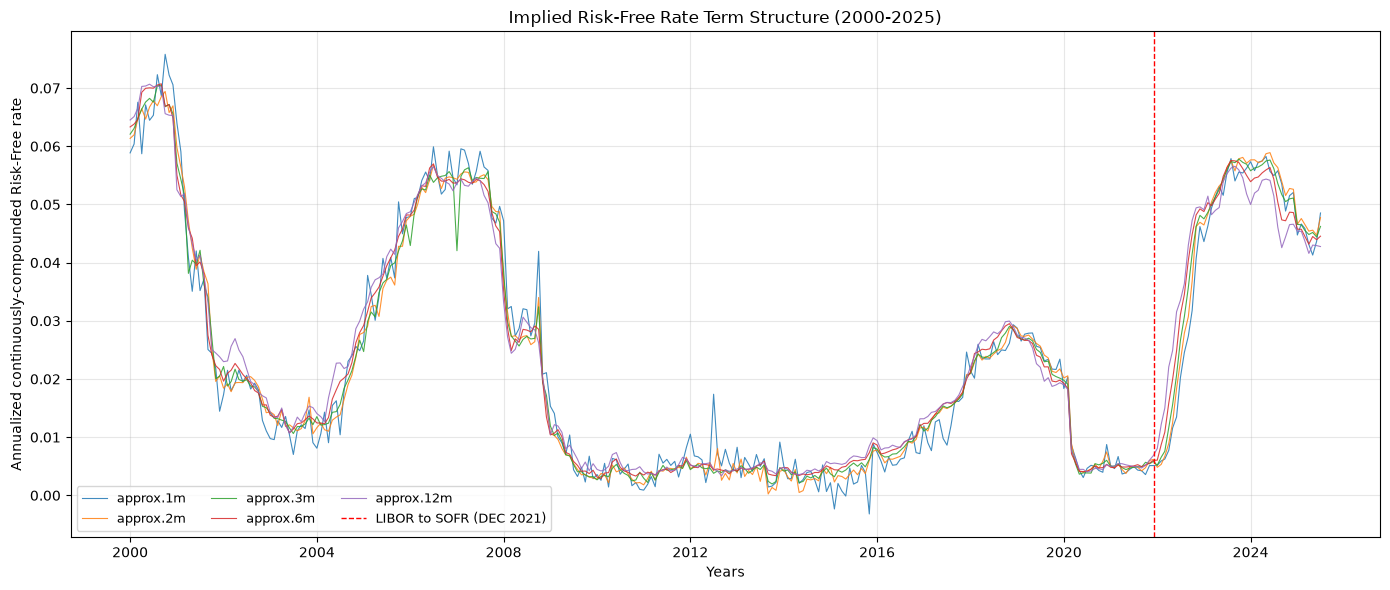

In [25]:
Table["date"] = pd.to_datetime(Table["date"])
Table["year-to-month"] = Table["date"].dt.to_period("M")

Table["maturity_label"] = pd.cut(Table["expiry"], 
                                 bins=[0,45,75,135,270,400], 
                                 labels=["approx.1m", "approx.2m","approx.3m","approx.6m","approx.12m"], 
                                 right=False)

rate_panel = (Table.groupby(["year-to-month","maturity_label"], observed=True)["r_annualized"].median().unstack("maturity_label"))

fig, axis = plt.subplots(figsize=(14,6))
for col in rate_panel.columns:
    axis.plot(rate_panel.index.to_timestamp(),rate_panel[col], linewidth=0.8, label=col, alpha=0.85)

axis.axvline(pd.Timestamp("2021-12-08"), color="red", linestyle="--",linewidth=1, label = "LIBOR to SOFR (DEC 2021)")
axis.set_title("Implied Risk-Free Rate Term Structure (2000-2025)")
axis.set_ylabel("Annualized continuously-compounded Risk-Free rate")
axis.set_xlabel("Years")
axis.legend(ncol = 3, fontsize = 9)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("implied_rate_term_structure.pdf", dpi =300)
rate_panel.to_csv("implied_rate_term_structure.csv")



for paper:
* The risk-free rate derived through put-call parity relects the market's effective discount rate for option price, without taking intro account factors such as funding cost differences, divident estimation errors, or market stress inherent in published risk-free rate such as the Secured Overnight Financing Rate (SOFR). 

### analysis
correlation = 0.999, and mean absolute % diff < 0.05% overall,

In [131]:
forward_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148194 entries, 0 to 148193
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               148194 non-null  str    
 1   exdate             148194 non-null  str    
 2   expiry             148194 non-null  int64  
 3   forward_price      148194 non-null  float64
 4   forward_price_ols  148194 non-null  float64
 5   discount_factor    148194 non-null  float64
 6   r_annualized       148194 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 10.7 MB


In [27]:
forward_df.to_csv("forward_price_data.csv", index=False)

## variance risk premium returns

### the economics and asset pricing of the variance risk premium

The variance risk premium (VRP) is not the direct compensation for holding equity risk itself, but rather the reward investors require to justify bearing exposure to the unpredictable fluctuations in market volatility over time. It is formally defined as the gap between the market’s risk-neutral expectation of future variance, and the realised variance. Beyond independent volatility shocks, return variance can vary stochastically based on multiple theoretically distinct reasons. This can be through its correlation, with the underlying assets stock price or return, as captured by constant elasticity of variance model investigated by Beckers (1980) who find an inverse relationship between a company’s stock price and its return volatility. The variation in returns can also be attributed to independent fluctuations as a distinct source of risk unrelated to price movements, as in the stochastic volatility models of Heston (1993).

For the S&P 500, a closely related measure is the VIX premium, defined as the difference between the risk-neutral and physical expectations of the future VIX index level as in Cheng (2019). This premium is non-zero echoing the foundational equilibrium framework from French et al. (1987), who find that the expected market risk premium is positively related to the predictable component of stock market volatility, driven by volatility clustering, providing early evidence that investors demand greater returns in anticipation of rising volatility. Recent work by Feunou et al. (2017) provides further evidence of a positive and significant link between the downside VRP and the equity premium by deconstructing volatility based on the behavioural assumption that investors view it asymmetrically. According to research, this negative unconditional volatility and risk premia is widely attributed to risk averse market participants’ demand for volatility insurance to hedge equity portfolios against severe market drawdowns (Carr and Wu, 2009; Bakshi and Kapadia, 2003). 

Under Epstein-Zin-Weil recursive preferences calibrated with standard preference for the early resolution of time-varying uncertainty, an agent’s marginal utility, is determined by their lifetime utility (Epstein and Zin, 1991). As heightened future volatility reduces lifetime utility, investors exhibit a strong intertemporal hedging demand to protect against shocks to future expected volatility. The VRP emerges as a priced factor whereby its temporal fluctuations can be captured by incorporating a time-varying volatility-of-volatility state variable (Bollerslev et al., 2009; Barndorff-Nielsen and Veraart., 2012). Additionally, the VRP represents compensation for highly persistent, expected consumption growth prospects and fluctuating economic uncertainty according to Drechsler and Yaron (2011), who extend the long-run risk model of Bansal and Yaron (2004) to connect the option-implied risk premium to a structural model of macroeconomic fundamentals and investor preferences. 
In predictive finance and options literature, the conventional approach for deriving the VRP introduces a profound set of statistical, econometric and observational challenges. This is due to a timing mismatch between spot market volatility shocks, which are observed in real time through implied volatility, and their eventual realisation as observed variance resulting in difficulty when simultaneously measuring them at a given time to extract the risk premia (Todorov, 2010). Some studies overcome this by relying on ex-post (after the event) realised variance as a substitute for the ex-ante (before the event) expected variance based on the assumption that on average, realised variance is an unbiased proxy of investor expectations. This results in measurement and estimation noise due to realised variance containing high-frequency price jumps and sampling errors that do not reflect ex-ante expectations as highlighted in Bollerslev et al. (2009). Alternatively, the conditional expectation of variance can be estimated using historical parametric forecasting models such as GARCH (Generalized Autoregressive Conditional Heteroskedasticity) or ARMA (Autoregressive Moving-Average) as in Liu et al. (2015). However, they fail to capture differing rates of mean reversion and are disconnected from economic fundamentals as they rely on a single persistence parameter. Modern studies address the term-structure dynamics by applying advanced multi-factor pricing models, such as the three-factor self-exciting stochastic volatility model proposed by Li and Zinna (2018). However, such frameworks are highly computationally intensive requiring parallel computing to filter and estimate latent state variables. 
To bypass these hurdles, instead of estimating the unobservable expectations of variance under the physical measure, several studies have focused on tracking the ex-post realized returns of variance-sensitive assets such as delta-neutral straddles or synthetic variance swaps. Due to delta-hedging removing the portfolio’s directional exposure, these assets function as direct, model-free empirical proxies for the realized variance risk premium whereby their instantaneous returns reflecting volatility innovations under stochastic volatility allowing for their use in tradeable strategies (Guo et al., 2023; Cremers et al., 2016; Johnson., 2017). Additionally, to investigate the information content embedded in the S&P 500 implied volatility (IV) term structure regarding the risk premia at varying horizons (30, 60, 90, 180 and 360 days), the empirical design must align the daily option-implied predictors with corresponding constant maturity VRP proxies. Implementing this daily, multi-maturity framework via constant-maturity interpolation is imperative to prevent maturity contraction biases and avoids discrete roll-yield distortions enabling continuous, daily time series measures suitable for predictive regressions according to Konstantinidi and Skiadopoulos (2016). 


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27397018 entries, 0 to 27397017
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   date             str    
 1   exdate           str    
 2   cp_flag          str    
 3   strike_price     float64
 4   best_bid         float64
 5   best_offer       float64
 6   volume           int64  
 7   open_interest    int64  
 8   impl_volatility  float64
 9   optionid         int64  
 10  am_settlement    int64  
 11  expiry           int64  
 12  mid_price        float64
dtypes: float64(5), int64(5), str(3)
memory usage: 3.2 GB


In [132]:
data["date"] = pd.to_datetime(data["date"])
data["exdate"] = pd.to_datetime(data["exdate"])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27397018 entries, 0 to 27397017
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[us]
 1   exdate           datetime64[us]
 2   cp_flag          str           
 3   strike_price     float64       
 4   best_bid         float64       
 5   best_offer       float64       
 6   volume           int64         
 7   open_interest    int64         
 8   impl_volatility  float64       
 9   optionid         int64         
 10  am_settlement    int64         
 11  expiry           int64         
 12  mid_price        float64       
dtypes: datetime64[us](2), float64(5), int64(5), str(1)
memory usage: 2.7 GB


!!! must redo build_vrp as date and exdate were not in datetime. 

In [133]:
vrp_daily = build_vrp(data)

In [134]:
vrp_daily.head()

,date,next_date,maturity,variance_swap_return_daily,straddle_return_daily
0,2000-01-03,2000-01-04,12m,0.038730,0.024623
1,2000-01-04,2000-01-05,12m,0.010957,0.004495
2,2000-01-05,2000-01-06,12m,-0.027130,-0.009272
3,2000-01-06,2000-01-07,12m,0.055477,0.004485
4,2000-01-07,2000-01-10,12m,-0.042418,-0.012925


In [135]:
vrp_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 38592 entries, 0 to 38591
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        38592 non-null  datetime64[us]
 1   next_date                   38592 non-null  datetime64[us]
 2   maturity                    38592 non-null  str           
 3   variance_swap_return_daily  22492 non-null  float64       
 4   straddle_return_daily       35419 non-null  float64       
dtypes: datetime64[us](2), float64(2), str(1)
memory usage: 1.6 MB


In [136]:
vrp_daily.to_csv("updated_VRP_daily_data.csv", index=False)

In [137]:
import importlib
import variance_risk_premium_data
importlib.reload(variance_risk_premium_data)
from variance_risk_premium_data import compounded_returns

In [138]:
#added winsorizing change to function.
vrp_panel = compounded_returns(vrp_daily)


In [149]:
vrp_panel.to_csv("updated_VRP_panel_data.csv", index=False)

In [139]:
vrp_panel.head()

,date,next_date,maturity,variance_swap_return_daily,straddle_return_daily,variance_swap_return_weekly,straddle_return_weekly,variance_swap_return_monthly,straddle_return_monthly
0,2000-01-03,2000-01-04,12m,0.038730,0.024623,0.032559,0.011020,0.043406,-0.017346
1,2000-01-04,2000-01-05,12m,0.010957,0.004495,0.026172,-0.006540,0.015525,-0.043502
2,2000-01-05,2000-01-06,12m,-0.027130,-0.009272,0.033494,-0.009391,-0.017563,-0.055623
3,2000-01-06,2000-01-07,12m,0.055477,0.004485,0.064487,0.006059,0.015672,-0.045495
4,2000-01-07,2000-01-10,12m,-0.042418,-0.012925,-0.020115,-0.000513,-0.027388,-0.044886


In [3]:
vrp_daily = pd.read_csv("updated_VRP_daily_data.csv")
vrp_panel = pd.read_csv("updated_VRP_panel_data.csv")

vrp_daily["date"] = pd.to_datetime(vrp_daily["date"])
vrp_daily["next_date"] = pd.to_datetime(vrp_daily["next_date"])

vrp_panel["date"] = pd.to_datetime(vrp_panel["date"])
vrp_panel["next_date"] = pd.to_datetime(vrp_panel["next_date"])


In [4]:
print(vrp_panel.info())
print(vrp_daily.info())

<class 'pandas.DataFrame'>
RangeIndex: 38592 entries, 0 to 38591
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          38592 non-null  datetime64[us]
 1   next_date                     38592 non-null  datetime64[us]
 2   maturity                      38592 non-null  str           
 3   variance_swap_return_daily    22492 non-null  float64       
 4   straddle_return_daily         35419 non-null  float64       
 5   variance_swap_return_weekly   7982 non-null   float64       
 6   straddle_return_weekly        32367 non-null  float64       
 7   variance_swap_return_monthly  1906 non-null   float64       
 8   straddle_return_monthly       23369 non-null  float64       
dtypes: datetime64[us](2), float64(6), str(1)
memory usage: 2.7 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 38592 entries, 0 to 38591
Data columns (total 5 columns):
 #   Col

## descriptive statistics of VRP panel

# 3.4 The Variance Risk Premium Data

---

We apply two model-free, variance-sensitive asset return series as proxies for the variance risk premium (VRP):

| Instrument | Methodology | Source |
|---|---|---|
| ATM straddle portfolio returns | Coval and Shumway (2001) | Constructed from OptionMetrics SPX data |
| Synthetic variance swap returns | Dew-Becker et al. (2017); Carr and Wu (2008) | Constructed from OptionMetrics SPX data |

This approach avoids the measurement error inherent in computing realised variance directly from historical index returns — specifically the contamination from high-frequency price jumps and sampling noise that affects ex-post realised variance estimates (Bollerslev et al., 2009). Both instruments are directly investable (up to transaction costs), making their returns economically interpretable as the actual compensation earned for bearing variance risk.

The VRP proxies are aligned with the **level factor** $\gamma_0$ of the IV curve, as the straddle and variance swap returns correspond to the risk-neutral variance embedded in the ATM implied volatility surface.

---

## 3.4.1 S&P 500 Straddle Returns

### What a Straddle Is

An **option straddle** is a strategy that simultaneously holds a long position in both a call and a put option on the same underlying asset, with the **same maturity and strike price**. At-the-money (ATM) straddles are defined as positions where the strike price equals (or is closest to) the current underlying asset price, giving the portfolio approximately zero net delta.

Because delta-hedging removes directional exposure, the straddle's return is driven primarily by **volatility innovations** — it gains when realised volatility exceeds the implied volatility priced into the options at entry, and loses when it falls short. Empirically, long ATM straddles produce **negative average returns**, consistent with a negative variance risk premium earned by buyers of variance (Arisoy, 2010; Barinov, 2008).

### Construction

We follow Coval and Shumway (2001), as derived formally in Appendix A1:

1. SPX options are grouped by moneyness level — ATM options are identified as those where the difference between the underlying asset price and strike price is within zero.
2. Individual daily option returns are computed for both the ATM call and ATM put.
3. The **daily straddle return** is the equal-weighted average of the ATM call and put returns:

$$r_t^{\text{straddle}} = \frac{1}{2}\left(r_t^{\text{call}} + r_t^{\text{put}}\right)$$

4. Daily returns are compounded to weekly (5-day) and monthly (21-day) horizons for empirical tests.

> **Implementation note:** Straddle returns are constructed in `straddle_returns.py`. The function `select_atm_straddle()` identifies the nearest-to-ATM strike on each day, and `revalue_next_day()` marks the position to market using the following day's quotes. Only options with a positive best bid at both $t$ and $t+1$ are accepted to guard against stale zero-bid quotes.

---

## 3.4.2 Synthetic Variance Swaps

### What a Variance Swap Is

A **variance swap** is an OTC financial derivative in which two parties agree to exchange cash flows at maturity based on the realised volatility of a specified underlying asset:

| Party | Cash flow |
|---|---|
| **Fixed payer** | Pays the variance swap strike — the fixed rate of implied variance set at contract initiation |
| **Floating receiver** | Receives the realised variance accumulated over the contract's life |

The payoff to the fixed payer at maturity is:

$$\text{Payoff} = N \cdot \left(\sigma^2_{\text{realised}} - K_{\text{var}}\right)$$

where $N$ is the notional, $\sigma^2_{\text{realised}}$ is the annualised realised variance over the contract period, and $K_{\text{var}}$ is the variance swap strike agreed at initiation. When implied variance systematically exceeds realised variance — the empirical regularity underlying the VRP — the fixed payer loses and the fixed receiver earns the variance risk premium.

### Synthetic Replication

Since direct OTC variance swap quotes are not publicly available over the full 2000–2025 sample, we replicate the variance swap payoff synthetically following the span-replication approach of Carr and Wu (2008) and the implementation of Dew-Becker et al. (2017).

The key result from Britten-Jones and Neuberger (2000) is that the expected risk-neutral integrated variance over $[t, T]$ can be spanned by a **static, continuously weighted portfolio of OTM options**:

$$\mathbb{E}^{\mathbb{Q}}_t\left[\int_t^T \sigma^2_s \, ds\right] = 2 \int_0^{\infty} \frac{1}{K^2} \left[c_t(K)\,\mathbf{1}_{K > F_t} + p_t(K)\,\mathbf{1}_{K \leq F_t}\right] dK$$

In practice, using the discrete cross-section of available SPX strikes, the synthetic variance swap value at time $t$ is approximated as:

$$v_t = \sum_{i} w_i \cdot \text{mid}_i(t)$$

where each weight is:

$$w_i = \frac{2 \,\Delta K_i}{K_i^2}$$

with $\Delta K_i$ the interval width around strike $K_i$ and $\text{mid}_i(t)$ the option mid-price. OTM puts are used for strikes below the forward price $F_0$ and OTM calls for strikes above, consistent with the Carr and Wu (2008) replication.

The **daily variance swap return** is then the holding-period return on this portfolio:

$$r_t^{\text{VS}} = \frac{v_{t+1}}{v_t} - 1$$

where $v_{t+1}$ is the value of the **same** set of option contracts revalued at time $t+1$ using the following day's mid-prices.

### Constant-Maturity Construction

Since there is typically no option expiry exactly $T^*$ months ahead, we form the target-maturity variance swap as a **linear combination of the two bracketing expiries** $T_1 < T^* < T_2$:

$$v_t^{T^*} = w_1 \cdot v_t^{T_1} + w_2 \cdot v_t^{T_2}$$

$$w_1 = \frac{T_2 - T^*}{T_2 - T_1}, \qquad w_2 = \frac{T^* - T_1}{T_2 - T_1}, \qquad w_1 + w_2 = 1$$

This mirrors the CBOE VIX construction methodology. Target maturities are $T^* \in \{30, 60, 90, 120, 180, 360\}$ days.

### Revaluation and Coverage Requirement

At time $t+1$, the same option contracts ($t$ positions) are revalued using next-day quotes. A minimum coverage threshold of **95%** of the strip's notional weight must be matched at $t+1$ (i.e., valid quotes exist for at least 95% of the weighted strip by value). If coverage falls below this threshold, the daily return is set to `NaN`. Missing legs that fall within the coverage threshold are zero-filled, which is conservative — it slightly understates $v_{t+1}$ relative to renormalising weights, avoiding the upward bias in percentage returns that renormalisation would introduce.

> **Implementation note:** Variance swap returns are constructed in `variance_swap_returns.py`. The function `otm_strip_weights()` builds the weighted portfolio, and `revalue_next_day()` applies the 95% coverage filter. The function `constant_maturity_return()` in `variance_risk_premium_data.py` handles the two-expiry linear interpolation and assembles the daily panel. Weekly and monthly compound returns are constructed in `compounded_returns()`.

---

## Return Horizon Summary

Daily returns from both instruments are compounded forward to produce three return horizons for the regression analysis:

| Horizon | Construction | NW lags used |
|---|---|---|
| **Daily** | Raw return from $t$ to $t+1$ | 1 lag |
| **Weekly** | Compounded: $\prod_{j=1}^{5}(1 + r_{t+j}) - 1$ | 4 lags |
| **Monthly** | Compounded: $\prod_{j=1}^{21}(1 + r_{t+j}) - 1$ | 20 lags |

A single missing daily return within any compounding window nullifies the entire weekly or monthly observation for that window anchor — the rolling compound requires an unbroken sequence of valid daily returns.

#### prior to winsorization


presence of extreme values. 

-
| measure | value |
| --- | --- |
|maximum variance swap return daily |       179.11078646886764%|
|average variance swap return daily |       1.701405784135263%|
|maximum straddle return daily   |          64.436248682824%|
|average straddle return daily    |         -0.11158931900968516%|
|maximum variance swap return weekly   |    864.5709376564122%|
|average variance swap return weekly   |    5.07586387819512%|
|maximum straddle return weekly        |    179.23310658110947%|
|average straddle return weekly         |   -0.4802476703699969%|

table 2

| index |      date| maturity | variance_swap_return_daily|
|---|---|---|---|
|14659 |2007-02-26 |      2m  |                  1.791108|
|12783 |2025-04-03  |     1m  |                  1.756096|
|11573 |2020-06-10   |    1m  |                  1.697379|
|11512 |2020-03-13   |    1m  |                  1.686566|
|12616 |2024-08-02   |    1m  |                  1.651457|
|12782 |2025-04-02   |    1m  |                  1.493834|
|10364 |2015-08-20   |    1m  |                  1.459629|
|10576 |2016-06-23   |    1m  |                  1.457141|
|17944 |2020-03-13   |    2m  |                  1.443892|
|11510 |2020-03-11   |    1m  |                  1.416949|
|10629 |2016-09-08   |    1m  |                  1.416342|
|9348  |2011-08-05   |    1m  |                  1.414225|
|11154 |2018-10-09   |    1m  |                  1.384304|
|10801 |2017-05-16   |    1m  |                  1.364920|
|24376 |2020-03-13   |    3m  |                  1.342895|
|9346  |2011-08-03   |    1m  |                  1.340450|
|11497 |2020-02-21   |    1m  |                  1.339759|
|19048 |2024-08-02   |    2m  |                  1.237454|
|18005 |2020-06-10   |    2m  |                  1.205220|
|19215 |2025-04-03   |    2m  |                  1.185976|

Extreme counts by maturity:
maturity
1m    25
2m     9
3m     3
4m     1
6m     1
Name: count, dtype: int64

Extreme counts by year:
year
2007     2
2008     1
2011     4
2013     1
2015     2
2016     2
2017     2
2018     5
2020    11
2021     1
2024     4
2025     4
Name: count, dtype: int64



In [140]:
vrp_panel.sample(20)

,date,next_date,maturity,variance_swap_return_daily,straddle_return_daily,variance_swap_return_weekly,straddle_return_weekly,variance_swap_return_monthly,straddle_return_monthly
14327,2005-10-27,2005-10-28,2m,NaN,0.008391,NaN,-0.007764,NaN,-0.087416
7234,2003-03-17,2003-03-18,1m,NaN,NaN,NaN,NaN,NaN,NaN
12404,2023-09-28,2023-09-29,1m,NaN,-0.009931,NaN,-0.036283,NaN,NaN
6019,2023-12-05,2023-12-06,12m,0.007996,-0.003313,-0.080634,0.004991,NaN,0.050019
1074,2004-04-14,2004-04-15,12m,-0.004447,-0.010994,0.010771,-0.017340,-0.018356,-0.034263
29240,2013-12-18,2013-12-19,4m,NaN,-0.001978,NaN,NaN,NaN,NaN
15820,2011-10-03,2011-10-04,2m,-0.153255,-0.035656,NaN,-0.046800,NaN,0.044933
31165,2021-08-12,2021-08-13,4m,-0.019485,-0.007327,0.261150,0.062560,NaN,-0.033507
28930,2012-09-24,2012-09-25,4m,0.074587,0.020704,NaN,0.015418,NaN,NaN
30673,2019-08-29,2019-08-30,4m,0.015097,0.009114,NaN,-0.028198,NaN,-0.070933


In [141]:
# review of returns
print(f"maximum variance swap return daily:        {vrp_panel["variance_swap_return_daily"].max()*100}%")
print(f"average variance swap return daily:        {vrp_panel["variance_swap_return_daily"].mean()*100}%")

print(f"\nmaximum straddle return daily:             {vrp_panel["straddle_return_daily"].max()*100}%")
print(f"average straddle return daily:             {vrp_panel["straddle_return_daily"].mean()*100}%")


print(f"\nmaximum variance swap return weekly:       {vrp_panel["variance_swap_return_weekly"].max()*100}%")
print(f"average variance swap return weekly:       {vrp_panel["variance_swap_return_weekly"].mean()*100}%")


print(f"\nmaximum straddle return weekly:            {vrp_panel["straddle_return_weekly"].max()*100}%")
print(f"average straddle return weekly:            {vrp_panel["straddle_return_weekly"].mean()*100}%")


maximum variance swap return daily:        124.90323965454539%
average variance swap return daily:        1.0956269990009213%

maximum straddle return daily:             27.77588903243351%
average straddle return daily:             -0.12868226110195224%

maximum variance swap return weekly:       437.4528356233178%
average variance swap return weekly:       1.6917652875237565%

maximum straddle return weekly:            115.2356044106494%
average straddle return weekly:            -0.5731571187983596%


In [142]:
# NaN rate by maturity and horizon
for mat in ["1m","2m","3m","4m","6m","12m"]:
    sub = vrp_panel[vrp_panel["maturity"] == mat]
    is_sub = sub[pd.to_datetime(sub["date"]) >= pd.Timestamp("2015-12-31")]
    print(f"\n{mat} — out-of-sample (2015–2025):")
    for col in ["variance_swap_return_daily",
                "variance_swap_return_weekly", 
                "variance_swap_return_monthly"]:
        n = is_sub[col].notna().sum()
        print(f"  {col}: {n} valid observations")


1m — out-of-sample (2015–2025):
  variance_swap_return_daily: 1093 valid observations
  variance_swap_return_weekly: 50 valid observations
  variance_swap_return_monthly: 0 valid observations

2m — out-of-sample (2015–2025):
  variance_swap_return_daily: 1292 valid observations
  variance_swap_return_weekly: 105 valid observations
  variance_swap_return_monthly: 0 valid observations

3m — out-of-sample (2015–2025):
  variance_swap_return_daily: 1559 valid observations
  variance_swap_return_weekly: 285 valid observations
  variance_swap_return_monthly: 0 valid observations

4m — out-of-sample (2015–2025):
  variance_swap_return_daily: 1852 valid observations
  variance_swap_return_weekly: 740 valid observations
  variance_swap_return_monthly: 65 valid observations

6m — out-of-sample (2015–2025):
  variance_swap_return_daily: 1847 valid observations
  variance_swap_return_weekly: 943 valid observations
  variance_swap_return_monthly: 145 valid observations

12m — out-of-sample (2015–2

In [143]:
# worst offenders
extreme = vrp_panel[
    vrp_panel["variance_swap_return_daily"].abs() > 1.0  
].sort_values("variance_swap_return_daily", ascending=False)

print(extreme[["date","maturity","variance_swap_return_daily"]].head(20))

# cluster by maturity
print("\nExtreme counts by maturity:")
print(extreme["maturity"].value_counts())

# cluster by date (known stress periods vs random days)
extreme["year"] = pd.to_datetime(extreme["date"]).dt.year
print("\nExtreme counts by year:")
print(extreme["year"].value_counts().sort_index())

            date maturity  variance_swap_return_daily
9346  2011-08-03       1m                    1.249032
9348  2011-08-05       1m                    1.249032
12782 2025-04-02       1m                    1.249032
12616 2024-08-02       1m                    1.249032
11573 2020-06-10       1m                    1.249032
11512 2020-03-13       1m                    1.249032
11510 2020-03-11       1m                    1.249032
12783 2025-04-03       1m                    1.249032
11497 2020-02-21       1m                    1.249032
11154 2018-10-09       1m                    1.249032
10629 2016-09-08       1m                    1.249032
10985 2018-02-07       1m                    1.170667
11507 2020-03-06       1m                    1.154360
11500 2020-02-26       1m                    1.119294
11942 2021-11-24       1m                    1.083220
11192 2018-12-03       1m                    1.079181
9356  2011-08-17       1m                    1.077394

Extreme counts by maturity:

### errors in vrp data:

possible explanations:

* could be due to influx of 0DTE position or covid 19
* could be in construction of variance compounded return
suggestion: late January and February of 2020, SPX hit all time highs. this let to vix standing around 12-14 % which is extremely calm.
short dated otm options became nearly worthless making the ((v_t)-variance return at time t) nearly worthless. 
when covid cases surged, VIX surged to 82.7 % making those same near-worthless OTM options repriced explosively 
overnight. a strip worth 0,2 on day t repriced to 3.6 on day t+1 gives a return up to 1700%.

this explains the maturity clustering - 25 of 39 extreme observations are at 1m. short dated options are more sensitive
to spot volatility level and most likely to have near-zero strip values during calm periods

* explanation for abnormal weekly and monthly compounded returns



#### observed variance risk premium returns 
 
observation count summary

In [5]:
rows = []
for mat in ["1m","2m","3m","4m","6m","12m"]:
    panel = vrp_panel[vrp_panel["maturity"] == mat]
    in_sampl = vrp_panel[pd.to_datetime(vrp_panel["date"]) <=pd.Timestamp("2015-12-31")]
    out_sampl = vrp_panel[pd.to_datetime(vrp_panel["date"]) > pd.Timestamp("2015-12-31")]

    for period_label, period in [("in-sample", in_sampl), ("out-of-sample",out_sampl)]:
        rows.append({
            "maturity":mat,
            "period": period_label,
            "variance swap daily": period["variance_swap_return_daily"].notna().sum(),
            "straddle daily": period["straddle_return_daily"].notna().sum(),
            "variance swap weekly": period["variance_swap_return_weekly"].notna().sum(),
            "straddle weekly": period["straddle_return_weekly"].notna().sum(),
            "variance swap monthly": period["variance_swap_return_monthly"].notna().sum(),
            "straddle monthly": period["straddle_return_monthly"].notna().sum(),
        })
vrp_error_summary = pd.DataFrame(rows)
vrp_error_summary

,maturity,period,variance swap daily,straddle daily,variance swap weekly,straddle weekly,variance swap monthly,straddle monthly
0,1m,in-sample,12891,21516,4698,19620,1413,14049
1,1m,out-of-sample,9601,13903,3284,12747,493,9320
2,2m,in-sample,12891,21516,4698,19620,1413,14049
3,2m,out-of-sample,9601,13903,3284,12747,493,9320
4,3m,in-sample,12891,21516,4698,19620,1413,14049
5,3m,out-of-sample,9601,13903,3284,12747,493,9320
6,4m,in-sample,12891,21516,4698,19620,1413,14049
7,4m,out-of-sample,9601,13903,3284,12747,493,9320
8,6m,in-sample,12891,21516,4698,19620,1413,14049
9,6m,out-of-sample,9601,13903,3284,12747,493,9320


In [27]:
from scipy.stats import skew, kurtosis
import statsmodels.api as sm

mat_order = ["1m","2m","3m","4m","6m","12m"]

horizons = [
    ("daily", "straddle_return_daily", 1),
    ("weekly", "straddle_return_weekly", 4),
    ("monthly", "straddle_return_monthly", 20),
]
def nw_stat(
        val: pd.Series,
        lag: int,
):
    y = val.to_numpy()
    x = np.ones(len(y))
    result = sm.OLS(y,x).fit(cov_type="HAC", cov_kwds={"maxlags":lag,"use_correction":True})
    return float(result.tvalues[0]), float(result.pvalues[0])

rows =[]
for mat in mat_order:
    sub = vrp_panel[vrp_panel["maturity"] == mat]
    row = {"maturity":mat}

    for label, col, lag in horizons:
        vals = sub[col].dropna() *100

        t_stat, p_value = nw_stat(vals, lag)

        row[f" N_{label}"] = len(vals)
        row[f"mean {label}"] = round(vals.mean(),3)
        row[f"std {label}"] = round(vals.std(),3)
        row[f"skew {label}"] = round(skew(vals),3)
    
    rows.append(row)

straddke_h = pd.DataFrame(rows)
straddke_h

,maturity,N_daily,mean daily,std daily,skew daily,N_weekly,mean weekly,std weekly,skew weekly,N_monthly,mean monthly,std monthly,skew monthly
0,1m,5708,-0.328,5.513,1.886,4741,-1.465,12.718,2.155,2080,-5.424,39.136,5.229
1,2m,6258,-0.199,3.342,1.692,5728,-0.947,7.792,1.769,4340,-4.061,18.554,2.455
2,3m,6211,-0.114,2.605,1.476,5850,-0.485,6.339,1.737,4724,-2.171,15.875,3.975
3,4m,6231,-0.083,2.154,1.327,5862,-0.356,5.253,1.626,4537,-1.535,12.965,3.680
4,6m,6052,-0.052,1.713,1.187,5662,-0.312,4.135,1.325,4407,-1.529,9.381,1.574
5,12m,4959,0.020,1.165,0.894,4524,0.112,2.986,1.379,3281,0.353,7.340,2.011


#### statistics table of variance risk premium results

include downside deviation, coefficient of variation, mean absolute deviation, coefficient of variation,

In [7]:
from scipy.stats import skew, kurtosis 

In [22]:
vrp_panel.head()

,date,next_date,maturity,variance_swap_return_daily,straddle_return_daily,variance_swap_return_weekly,straddle_return_weekly,variance_swap_return_monthly,straddle_return_monthly
0,2000-01-03,2000-01-04,12m,0.038730,0.024623,0.032559,0.011020,0.043406,-0.017346
1,2000-01-04,2000-01-05,12m,0.010957,0.004495,0.026172,-0.006540,0.015525,-0.043502
2,2000-01-05,2000-01-06,12m,-0.027130,-0.009272,0.033494,-0.009391,-0.017563,-0.055623
3,2000-01-06,2000-01-07,12m,0.055477,0.004485,0.064487,0.006059,0.015672,-0.045495
4,2000-01-07,2000-01-10,12m,-0.042418,-0.012925,-0.020115,-0.000513,-0.027388,-0.044886


In [19]:
rows = []
maturity = ["1m","2m","3m","4m","6m","12m"]

for mat in maturity:
    s = vrp_panel[vrp_panel["maturity"]== mat]
    for asset, column in [("variance swap","variance_swap_return_daily"),
                          ("straddle","straddle_return_daily")]:
        vals = s[column].dropna() *100
        rows.append({
            "maturity":mat,
            "VRP asset": asset,
            "Mean (%)": round(vals.mean(),3),
            "std (%)": round(vals.std(),3),
            "skew": round(skew(vals),3),
            "kurt": round(kurtosis(vals),3),
            "Min (%)": round(vals.min(),3),
            "max (%)": round(vals.max(),3),
            "AR (1)" : round(pd.Series(vals.values).autocorr(lag=1),3),
        })
statistics_table = pd.DataFrame(rows)
statistics_table

,maturity,VRP asset,Mean (%),std (%),skew,kurt,Min (%),max (%),AR (1)
0,1m,variance swap,5.857,20.245,2.656,9.782,-24.436,124.903,0.100
1,1m,straddle,-0.328,5.513,1.886,5.922,-11.254,27.776,-0.023
2,2m,variance swap,2.328,12.798,2.571,10.256,-20.664,80.899,0.047
3,2m,straddle,-0.199,3.342,1.692,5.749,-7.660,17.362,0.018
4,3m,variance swap,1.022,9.428,2.299,8.547,-16.449,55.926,0.027
5,3m,straddle,-0.114,2.605,1.476,5.023,-6.628,13.089,0.048
6,4m,variance swap,0.378,7.699,2.021,7.218,-15.346,43.844,0.016
7,4m,straddle,-0.083,2.154,1.327,4.647,-5.775,10.685,0.055
8,6m,variance swap,0.057,6.013,1.703,5.668,-13.773,31.473,-0.008
9,6m,straddle,-0.052,1.713,1.187,4.474,-4.796,8.527,0.056


In [23]:
straddles = statistics_table[statistics_table["VRP asset"] == "straddle"]
straddles

,maturity,VRP asset,Mean (%),std (%),skew,kurt,Min (%),max (%),AR (1)
1,1m,straddle,-0.328,5.513,1.886,5.922,-11.254,27.776,-0.023
3,2m,straddle,-0.199,3.342,1.692,5.749,-7.660,17.362,0.018
5,3m,straddle,-0.114,2.605,1.476,5.023,-6.628,13.089,0.048
7,4m,straddle,-0.083,2.154,1.327,4.647,-5.775,10.685,0.055
9,6m,straddle,-0.052,1.713,1.187,4.474,-4.796,8.527,0.056
11,12m,straddle,0.020,1.165,0.894,3.115,-3.195,5.267,0.104


In [24]:
swaps = statistics_table[statistics_table["VRP asset"] == "variance swap"]
swaps

,maturity,VRP asset,Mean (%),std (%),skew,kurt,Min (%),max (%),AR (1)
0,1m,variance swap,5.857,20.245,2.656,9.782,-24.436,124.903,0.100
2,2m,variance swap,2.328,12.798,2.571,10.256,-20.664,80.899,0.047
4,3m,variance swap,1.022,9.428,2.299,8.547,-16.449,55.926,0.027
6,4m,variance swap,0.378,7.699,2.021,7.218,-15.346,43.844,0.016
8,6m,variance swap,0.057,6.013,1.703,5.668,-13.773,31.473,-0.008
10,12m,variance swap,-0.141,3.794,1.158,3.720,-10.301,17.043,-0.003


In [21]:
statistics_table.to_csv("variance_risk_stats.csv", index=False)

#### term structure of average vrp returns

how average returns vary across maturities for each instrument, 

mean daily return by maturity
1. variance swap returns decline from 6% at 30 days to near zero at 360 days-- somethings wrong?
2. straddle returns are almost flat near zero, and slightly negative across all maturities.


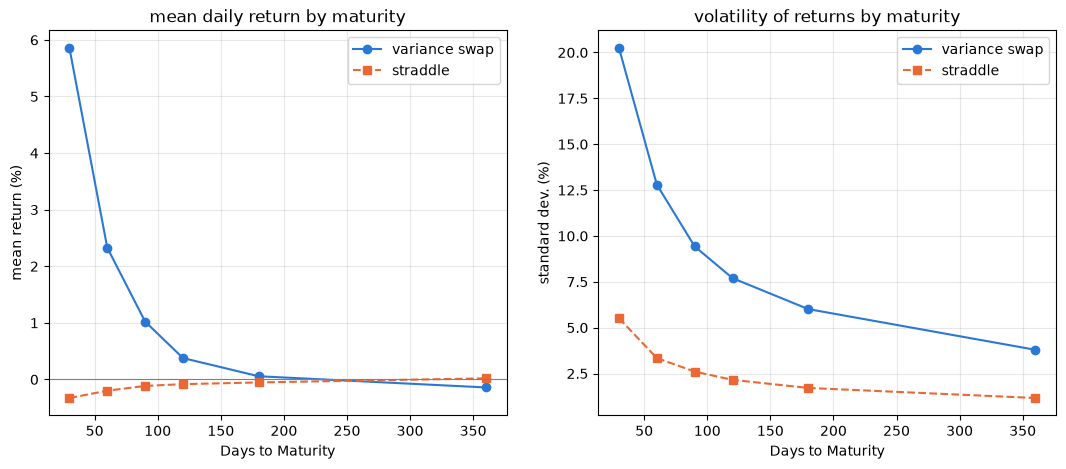

In [17]:
maturity = ["1m","2m","3m","4m","6m","12m"]
days = [30,60,90,120,180,360]

straddle_means = []
swaps_means = []
straddle_std = []
swap_std =[]

for mat in maturity:
    sub = vrp_panel[vrp_panel["maturity"] == mat]
    swaps_means.append(sub["variance_swap_return_daily"].mean()*100)
    straddle_means.append(sub["straddle_return_daily"].mean()*100)
    swap_std.append(sub["variance_swap_return_daily"].std()*100)
    straddle_std.append(sub["straddle_return_daily"].std()*100)

fig, (axis1, axis2) = plt.subplots(1,2, figsize=(13,5))

axis1.plot(days, swaps_means,"o-", label="variance swap", color="#2a78d6")
axis1.plot(days, straddle_means,"s--", label="straddle", color="#eb6834")
axis1.axhline(0, color="grey",linewidth=0.8)
axis1.set_title("mean daily return by maturity")
axis1.set_xlabel("Days to Maturity")
axis1.set_ylabel("mean return (%)")
axis1.legend()
axis1.grid(alpha=0.3)


axis2.plot(days, swap_std,"o-",label="variance swap", color="#2a78d6")
axis2.plot(days, straddle_std,"s--", label="straddle", color="#eb6834")
axis2.set_title("volatility of returns by maturity")
axis2.set_xlabel("Days to Maturity")
axis2.set_ylabel("standard dev. (%)")
axis2.legend()
axis2.grid(alpha=0.3)
fig.savefig("term structure vrp.png")

#### new table

In [10]:
vrp_panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 38592 entries, 0 to 38591
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          38592 non-null  datetime64[us]
 1   next_date                     38592 non-null  datetime64[us]
 2   maturity                      38592 non-null  str           
 3   variance_swap_return_daily    22492 non-null  float64       
 4   straddle_return_daily         35419 non-null  float64       
 5   variance_swap_return_weekly   7982 non-null   float64       
 6   straddle_return_weekly        32367 non-null  float64       
 7   variance_swap_return_monthly  1906 non-null   float64       
 8   straddle_return_monthly       23369 non-null  float64       
dtypes: datetime64[us](2), float64(6), str(1)
memory usage: 2.7 MB


In [ ]:
vrp_panel

In [150]:
print(f"vrp daily:\n{vrp_daily.info()}")
print(f"vrp_panel:\n{vrp_panel.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 38592 entries, 0 to 38591
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        38592 non-null  datetime64[us]
 1   next_date                   38592 non-null  datetime64[us]
 2   maturity                    38592 non-null  str           
 3   variance_swap_return_daily  22492 non-null  float64       
 4   straddle_return_daily       35419 non-null  float64       
dtypes: datetime64[us](2), float64(2), str(1)
memory usage: 1.6 MB
vrp daily:
None
<class 'pandas.DataFrame'>
RangeIndex: 38592 entries, 0 to 38591
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          38592 non-null  datetime64[us]
 1   next_date                     38592 non-null  datetime64[us]
 2   maturi

# implied volatility curve

required the out-of-the-money/ at-the-money filtered data with forward price merged in

use "cleaned_research_data.csv"

apply estimate_forward_curve()

merge forward_price

apply filter_otm_atm() to merged df

ensure date and exdate are in datetime

### the geometry and factorisation of the option smirk

The variance risk premium (VRP) is not the direct compensation for holding equity risk itself, but rather the reward investors require to justify bearing exposure to the unpredictable fluctuations in market volatility over time. It is formally defined as the gap between the market’s risk-neutral expectation of future variance, and the realised variance. Beyond independent volatility shocks, return variance can vary stochastically based on multiple theoretically distinct reasons. This can be through its correlation, with the underlying assets stock price or return, as captured by constant elasticity of variance model investigated by Beckers (1980) who find an inverse relationship between a company’s stock price and its return volatility. The variation in returns can also be attributed to independent fluctuations as a distinct source of risk unrelated to price movements, as in the stochastic volatility models of Heston (1993).

For the S&P 500, a closely related measure is the VIX premium, defined as the difference between the risk-neutral and physical expectations of the future VIX index level as in Cheng (2019). This premium is non-zero echoing the foundational equilibrium framework from French et al. (1987), who find that the expected market risk premium is positively related to the predictable component of stock market volatility, driven by volatility clustering, providing early evidence that investors demand greater returns in anticipation of rising volatility. Recent work by Feunou et al. (2017) provides further evidence of a positive and significant link between the downside VRP and the equity premium by deconstructing volatility based on the behavioural assumption that investors view it asymmetrically. According to research, this negative unconditional volatility and risk premia is widely attributed to risk averse market participants’ demand for volatility insurance to hedge equity portfolios against severe market drawdowns (Carr and Wu, 2009; Bakshi and Kapadia, 2003). 

Under Epstein-Zin-Weil recursive preferences calibrated with standard preference for the early resolution of time-varying uncertainty, an agent’s marginal utility, is determined by their lifetime utility (Epstein and Zin, 1991). As heightened future volatility reduces lifetime utility, investors exhibit a strong intertemporal hedging demand to protect against shocks to future expected volatility. The VRP emerges as a priced factor whereby its temporal fluctuations can be captured by incorporating a time-varying volatility-of-volatility state variable (Bollerslev et al., 2009; Barndorff-Nielsen and Veraart., 2012). Additionally, the VRP represents compensation for highly persistent, expected consumption growth prospects and fluctuating economic uncertainty according to Drechsler and Yaron (2011), who extend the long-run risk model of Bansal and Yaron (2004) to connect the option-implied risk premium to a structural model of macroeconomic fundamentals and investor preferences. 
In predictive finance and options literature, the conventional approach for deriving the VRP introduces a profound set of statistical, econometric and observational challenges. This is due to a timing mismatch between spot market volatility shocks, which are observed in real time through implied volatility, and their eventual realisation as observed variance resulting in difficulty when simultaneously measuring them at a given time to extract the risk premia (Todorov, 2010). Some studies overcome this by relying on ex-post (after the event) realised variance as a substitute for the ex-ante (before the event) expected variance based on the assumption that on average, realised variance is an unbiased proxy of investor expectations. This results in measurement and estimation noise due to realised variance containing high-frequency price jumps and sampling errors that do not reflect ex-ante expectations as highlighted in Bollerslev et al. (2009). Alternatively, the conditional expectation of variance can be estimated using historical parametric forecasting models such as GARCH (Generalized Autoregressive Conditional Heteroskedasticity) or ARMA (Autoregressive Moving-Average) as in Liu et al. (2015). However, they fail to capture differing rates of mean reversion and are disconnected from economic fundamentals as they rely on a single persistence parameter. Modern studies address the term-structure dynamics by applying advanced multi-factor pricing models, such as the three-factor self-exciting stochastic volatility model proposed by Li and Zinna (2018). However, such frameworks are highly computationally intensive requiring parallel computing to filter and estimate latent state variables. 
To bypass these hurdles, instead of estimating the unobservable expectations of variance under the physical measure, several studies have focused on tracking the ex-post realized returns of variance-sensitive assets such as delta-neutral straddles or synthetic variance swaps. Due to delta-hedging removing the portfolio’s directional exposure, these assets function as direct, model-free empirical proxies for the realized variance risk premium whereby their instantaneous returns reflecting volatility innovations under stochastic volatility allowing for their use in tradeable strategies (Guo et al., 2023; Cremers et al., 2016; Johnson., 2017). Additionally, to investigate the information content embedded in the S&P 500 implied volatility (IV) term structure regarding the risk premia at varying horizons (30, 60, 90, 180 and 360 days), the empirical design must align the daily option-implied predictors with corresponding constant maturity VRP proxies. Implementing this daily, multi-maturity framework via constant-maturity interpolation is imperative to prevent maturity contraction biases and avoids discrete roll-yield distortions enabling continuous, daily time series measures suitable for predictive regressions according to Konstantinidi and Skiadopoulos (2016). 


### sourcing data


In [6]:
from inital_clean import filter_otm_atm

In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27397018 entries, 0 to 27397017
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[us]
 1   exdate           datetime64[us]
 2   cp_flag          str           
 3   strike_price     float64       
 4   best_bid         float64       
 5   best_offer       float64       
 6   volume           int64         
 7   open_interest    int64         
 8   impl_volatility  float64       
 9   optionid         int64         
 10  am_settlement    int64         
 11  expiry           int64         
 12  mid_price        float64       
dtypes: datetime64[us](2), float64(5), int64(5), str(1)
memory usage: 2.7 GB


In [34]:
#data2 = pd.read_csv("cleaned_research_data.csv")
# lets use data from the begining of the study
data2 = data.copy()
forward_df2 = estimate_forward_curve(data2)

df = data2.merge(forward_df2[["date","exdate","expiry","forward_price"]], on=["date","exdate","expiry"], how="left")
filtered = filter_otm_atm(df)


filter summary
inital rows = 27397018 rows
after filtering call option data = 5147696 rows
after filerting put option data = 12098164 rows
number of dropped rows = 10151158
total kept rows = 17245860 rows


In [35]:
forward_df2.head()

,date,exdate,expiry,forward_price,forward_price_ols,discount_factor,r_annualized
0,2000-01-03,2000-01-22,18,1455.623284,1455.802901,0.999608,0.007950
1,2000-01-03,2000-02-19,46,1461.231821,1461.276253,0.995176,0.038373
2,2000-01-03,2000-03-18,74,1466.459393,1466.681146,0.988531,0.056897
3,2000-01-03,2000-06-17,165,1485.288410,1485.549046,0.971967,0.062897
4,2000-01-03,2000-09-16,256,1504.971041,1504.760544,0.955534,0.064851


In [36]:
filtered.head()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,optionid,am_settlement,expiry,mid_price,forward_price
2,2000-01-03,2000-06-17,P,1350.0,40.750,42.750,290,14570,0.257464,10016917,1,165,41.750,1485.288410
3,2000-01-03,2000-06-17,P,1275.0,27.250,29.250,0,5513,0.279201,10024738,1,165,28.250,1485.288410
4,2000-01-03,2000-03-18,C,1575.0,13.500,14.750,43,619,0.184711,10029228,1,74,14.125,1466.459393
5,2000-01-03,2000-02-19,C,1475.0,35.375,37.375,550,3366,0.202513,10032934,1,46,36.375,1461.231821
6,2000-01-03,2000-01-22,C,1535.0,2.000,2.750,77,77,0.176439,10036858,1,18,2.375,1455.623284


In [37]:
filtered = filtered.drop(columns=["forward_price"])
filtered.head()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,optionid,am_settlement,expiry,mid_price
2,2000-01-03,2000-06-17,P,1350.0,40.750,42.750,290,14570,0.257464,10016917,1,165,41.750
3,2000-01-03,2000-06-17,P,1275.0,27.250,29.250,0,5513,0.279201,10024738,1,165,28.250
4,2000-01-03,2000-03-18,C,1575.0,13.500,14.750,43,619,0.184711,10029228,1,74,14.125
5,2000-01-03,2000-02-19,C,1475.0,35.375,37.375,550,3366,0.202513,10032934,1,46,36.375
6,2000-01-03,2000-01-22,C,1535.0,2.000,2.750,77,77,0.176439,10036858,1,18,2.375


In [38]:
filtered.info()

<class 'pandas.DataFrame'>
Index: 17245860 entries, 2 to 27396997
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[us]
 1   exdate           datetime64[us]
 2   cp_flag          str           
 3   strike_price     float64       
 4   best_bid         float64       
 5   best_offer       float64       
 6   volume           int64         
 7   open_interest    int64         
 8   impl_volatility  float64       
 9   optionid         int64         
 10  am_settlement    int64         
 11  expiry           int64         
 12  mid_price        float64       
dtypes: datetime64[us](2), float64(5), int64(5), str(1)
memory usage: 1.8 GB


In [39]:
from Zhang_and_Xiang import (
    implied_volatility_curve,
    interpolate_constant_maturity,
    term_spreads,
    hump_factor,
)

In [40]:
vix_df = pd.read_csv("vix-2000-2025-prepped.csv")
vix_df["date"] = pd.to_datetime(vix_df["date"])
vix_series = vix_df.set_index("date")["vix"]

In [41]:

print(f"dataframe:\n{filtered.dtypes}")
print(f"forward data:\n{forward_df2.dtypes}")
print(f"vix series:\n{vix_series.dtypes}")

dataframe:
date               datetime64[us]
exdate             datetime64[us]
cp_flag                       str
strike_price              float64
best_bid                  float64
best_offer                float64
volume                      int64
open_interest               int64
impl_volatility           float64
optionid                    int64
am_settlement               int64
expiry                      int64
mid_price                 float64
dtype: object
forward data:
date                 datetime64[us]
exdate               datetime64[us]
expiry                        int64
forward_price               float64
forward_price_ols           float64
discount_factor             float64
r_annualized                float64
dtype: object
vix series:
float64


In [42]:
print(vix_series.index.dtype)

datetime64[us]


In [43]:
# Check the exact precision
print(f"filtered date dtype:    {filtered['date'].dtype}")      # datetime64[us]
print(f"vix_series index dtype: {vix_series.index.dtype}")      # must also be datetime64[us]

# The definitive test — spot-check one actual date
sample_date = filtered["date"].iloc[0]
print(f"\nSample date: {sample_date}  (type: {type(sample_date)})")
print(f"Found in vix_series: {sample_date in vix_series.index}")

filtered date dtype:    datetime64[us]
vix_series index dtype: datetime64[us]

Sample date: 2000-01-03 00:00:00  (type: <class 'pandas.Timestamp'>)
Found in vix_series: True


In [44]:
print(vix_series[vix_series.index.duplicated(keep=False)].head(10))

Series([], Name: vix, dtype: float64)


In [45]:
vix_series = vix_series[~vix_series.index.duplicated(keep="first")]
print(f"duplicates: {vix_series.index.duplicated().sum()}")

duplicates: 0


In [ ]:
#run when implied_vol_panel works
vix_series.to_csv("vix-2000-2025-prepped.csv", index=True)

### implied volatility panel analysis

# 3.2 Quantifying the Implied Volatility Curves

---

We follow the local expansion method proposed by Zhang and Xiang (2008) to quantify the shape of the implied volatility curve for each maturity across the moneyness function. The procedure has three steps:

1. The curve is parameterised locally by a **quadratic function** of the standardised moneyness variable.
2. It is mapped via the Breeden and Litzenberger (1978) identity into a risk-neutral distribution.
3. The quadratic coefficients are related in closed form to the **standard deviation, skewness, and excess kurtosis** of that risk-neutral distribution.

---

## Forward Price Estimation

Consider a portfolio constructed by selling one put and buying one call option with the same strike price and exercise date, where the payoff equals the forward price. Let $c_0(K)$ and $p_0(K)$ denote the market prices of the call and put option respectively with the same maturity $\tau$.

The implied forward price $F_0$ is obtained through the put-call parity relationship, evaluated at the strike price $K^*$ that minimises the absolute call-put price difference:

$$F_0 = K^* + e^{r\tau}\left(c_0(K^*) - p_0(K^*)\right) \tag{1}$$

$$\text{where} \quad K^* = \arg\min_{K} \left|c_0(K) - p_0(K)\right| \tag{2}$$

---

## Standardised Moneyness

Rather than working directly with the strike price, Zhang and Xiang (2008) define the moneyness variable $\xi$ as the logarithm of the strike price over the implied forward price, scaled by the standard deviation of the return to maturity — following the industry notation of Carr and Wu (2003) with a constant benchmark volatility:

$$\xi = \frac{\ln\!\left(\dfrac{K}{F_0}\right)}{\sigma\sqrt{\tau}} \tag{3}$$

| Symbol | Definition |
|--------|-----------|
| $\sigma$ | Standard deviation of returns, proxied by the VIX index |
| $F_0$ | Implied forward price |
| $K$ | Strike price |
| $\tau$ | Time to maturity (in years) |

The VIX provides a single, market-wide daily benchmark volatility for the denominator, ensuring that moneyness is measured on a standardised scale across maturities. A strike at $\xi = 0$ is exactly at-the-money; $\xi < 0$ denotes OTM put territory and $\xi > 0$ denotes OTM call territory.

---

## The Quadratic IV Curve

At a fixed maturity, a second-order polynomial describes implied volatility as a function of standardised moneyness:

$$IV(\xi) = \gamma_0\left(1 + \gamma_1 \xi + \gamma_2 \xi^2\right) \tag{4}$$

where $\gamma_0$, $\gamma_1$, and $\gamma_2$ are the **level**, **slope**, and **curvature** factors of the implied volatility smirk.

### Factor Interpretation

| Factor | Name | Economic Analogue |
|--------|------|-------------------|
| $\gamma_0$ | **Level** | ATM implied volatility — baseline spot variance of the underlying asset |
| $\gamma_1$ | **Slope** | Risk-reversal: long OTM call, short OTM put — captures the skew of the smile |
| $\gamma_2$ | **Curvature** | Butterfly spread: long one ITM call and one OTM call, short two ATM calls — captures the convexity of the smile |

The three factors are approximately proportional to the **risk-neutral standard deviation, skewness, and excess kurtosis** respectively, as shown by Bakshi, Kapadia and Madan (2003) under the Edgeworth expansion of the risk-neutral density.

> **Implementation note:** The curve is estimated via OLS across all available OTM and ATM options for each (date, expiry) pair, requiring a minimum of 5 observations. Implied volatility observations are sourced directly from OptionMetrics. See `Zhang_and_Xiang.py → fit_iv_curve()`.

---

# 3.3 Constant Maturity Factors and Term Spreads

---

Since each day's IV smirk is fitted independently for the day's available expiries, the resulting level, slope, and curvature factors are not directly comparable across dates at different maturities. We examine how the smirk evolves along the term structure over time through **linear interpolation** of the IV factors to a fixed set of constant maturities, matching CBOE VIX-style term structure conventions (Lin, 2013):

$$\text{Target maturities: } \{30,\ 60,\ 90,\ 120,\ 180,\ 360\} \text{ days} \equiv \{1\text{m},\ 2\text{m},\ 3\text{m},\ 4\text{m},\ 6\text{m},\ 12\text{m}\}$$

When the target maturity falls outside the available expiry range on a given day, the observation is excluded rather than extrapolated to avoid unstable out-of-range values.

---

## Level, Slope, and Curvature Term Spreads

On each day, factor term spreads are formed as the difference between the long-end (360-day) and short-end (30-day) constant-maturity factors:

$$\gamma_0^{360-30} = \gamma_0^{360} - \gamma_0^{30} \tag{5}$$

$$\gamma_1^{360-30} = \gamma_1^{360} - \gamma_1^{30} \tag{6}$$

$$\gamma_2^{360-30} = \gamma_2^{360} - \gamma_2^{30} \tag{7}$$

We additionally construct the **short-end spread** ($180 - 30$ days) and **long-end spread** ($360 - 180$ days) to capture distinct segments of the term structure:

| Spread Label | Definition | Segment |
|---|---|---|
| $\gamma_i^{180-30}$ | $\gamma_i^{180} - \gamma_i^{30}$ | Short-end (30 → 180 days) |
| $\gamma_i^{360-30}$ | $\gamma_i^{360} - \gamma_i^{30}$ | Full-term (30 → 360 days) |
| $\gamma_i^{360-180}$ | $\gamma_i^{360} - \gamma_i^{180}$ | Long-end (180 → 360 days) |

A **positive level spread** $(\gamma_0^{360-30} > 0)$ indicates an upward-sloping ATM IV term structure — contango — consistent with investors pricing greater long-run uncertainty than near-term uncertainty. A **negative spread** indicates backwardation. The regime indicator $D_t$ is constructed from the sign of the level spread (Section 3.5).

---

## The Hump Factor

Christoffersen et al. (2009) show that the volatility term structure is not necessarily monotonic — a single factor model does not capture the curvatures across maturities. Todorov (2010) further documents that investors' fear of future volatility jumps is sensitive to recent jump activity, producing non-linear dynamics concentrated at medium-term horizons.

To capture this, we introduce a **rate-normalised discrete second difference** across three nested maturity points — short ($\tau = 30$), middle ($\tau = 180$), and long ($\tau = 360$) — for each of the three IV curve factors:

$$H_0 = \frac{\left[\gamma_0^{360} - \gamma_0^{180}\right]}{180} - \frac{\left[\gamma_0^{180} - \gamma_0^{30}\right]}{150} \tag{8}$$

$$H_1 = \frac{\left[\gamma_1^{360} - \gamma_1^{180}\right]}{180} - \frac{\left[\gamma_1^{180} - \gamma_1^{30}\right]}{150} \tag{9}$$

$$H_2 = \frac{\left[\gamma_2^{360} - \gamma_2^{180}\right]}{180} - \frac{\left[\gamma_2^{180} - \gamma_2^{30}\right]}{150} \tag{10}$$

where $H_0$, $H_1$, and $H_2$ represent the **level**, **slope**, and **curvature hump** respectively. Each half is normalised by its span in days (180 and 150) before differencing, converting each segment into a **per-day rate of change**. This accounts for the unequal spans between the three anchor points, ensuring the comparison is made on equal-section terms.

### Hump Factor Interpretation

| Condition | Hump value | Economic meaning |
|---|---|---|
| Short-to-mid slope $\approx$ mid-to-long slope | $H \approx 0$ | Term structure is approximately linear — no hump |
| $\left[\gamma^{180} - \gamma^{30}\right] > \left[\gamma^{360} - \gamma^{180}\right]$ | $H < 0$ | Curve **bulges upward** at 180 days — genuine hump at medium maturity |
| $\left[\gamma^{180} - \gamma^{30}\right] < \left[\gamma^{360} - \gamma^{180}\right]$ | $H > 0$ | Curve **bulges downward** at 180 days — trough at medium maturity |

A negative $H_0$ indicates that the 180-day level factor is **elevated above** the linear interpolation between its 30-day and 360-day anchors — the market prices disproportionate variance risk at the medium-term horizon. This is the primary feature the hump factor is designed to detect beyond what the endpoint spread $\gamma_0^{360-30}$ can identify.

---

## Winsorisation

To account for outlier predictors on days with thin quoting or unstable IV curve fits, all nine term spread factors and three hump factors are **winsorised at the 0.5% tail cutoff of the whole sample**, following Guo et al. (2023) and Cao and Han (2013):

$$\text{Winsorisation limits: } (0.005,\ 0.005) \quad \Rightarrow \quad \text{clips bottom and top 0.5\% of each factor's full time series}$$

Winsorisation is applied **after** each factor's complete time series is constructed — not per (date, expiry) group — so the 0.5% threshold reflects the full-sample distribution of the factor.

> **Implementation note:** Term spreads and hump factors are computed in `Zhang_and_Xiang.py`. Functions `term_spreads()` and `hump_factor()` apply winsorisation internally before returning the final predictor series.

notes:
---
according to Zhang and Xiang (2008):
* "the implied volatility surface has all the information of market option prices. it reflects the risk-neutral distribution of underlying asset returns over different horizons"



In [6]:
implied_vol_panel = implied_volatility_curve(
    df=filtered,
    forward_df=forward_df2,
    vix_series=vix_series,
)

NameError: name 'filtered' is not defined

In [7]:
implied_vol_panel.to_csv("implied_volatility_panel_data.csv", index=False)
implied_vol_panel.head()

NameError: name 'implied_vol_panel' is not defined

In [3]:
implied_vol_panel.dtypes

NameError: name 'implied_vol_panel' is not defined

In [8]:
implied_vol_panel = pd.read_csv("implied_volatility_panel_data.csv")
implied_vol_panel["date"] = pd.to_datetime(implied_vol_panel["date"])
implied_vol_panel["exdate"] = pd.to_datetime(implied_vol_panel["date"])
implied_vol_panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 148178 entries, 0 to 148177
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       148178 non-null  datetime64[us]
 1   exdate     148178 non-null  datetime64[us]
 2   expiry     148178 non-null  int64         
 3   gamma0     148178 non-null  float64       
 4   gamma1     148178 non-null  float64       
 5   gamma2     148178 non-null  float64       
 6   r_squared  148178 non-null  float64       
 7   n_obs      148178 non-null  int64         
dtypes: datetime64[us](2), float64(4), int64(2)
memory usage: 9.0 MB


In [9]:
implied_vol_panel.head()

,date,exdate,expiry,gamma0,gamma1,gamma2,r_squared,n_obs
0,2000-01-03,2000-01-03,18,0.220587,-0.051871,0.001749,0.993983,37
1,2000-01-03,2000-01-03,46,0.220386,-0.054689,0.001103,0.990879,25
2,2000-01-03,2000-01-03,74,0.226847,-0.054257,-0.000240,0.993162,45
3,2000-01-03,2000-01-03,165,0.225199,-0.053960,-0.000148,0.990999,42
4,2000-01-03,2000-01-03,256,0.223009,-0.059362,-0.000329,0.990259,20


In [10]:

implied_vol_panel.head()

,date,exdate,expiry,gamma0,gamma1,gamma2,r_squared,n_obs
0,2000-01-03,2000-01-03,18,0.220587,-0.051871,0.001749,0.993983,37
1,2000-01-03,2000-01-03,46,0.220386,-0.054689,0.001103,0.990879,25
2,2000-01-03,2000-01-03,74,0.226847,-0.054257,-0.000240,0.993162,45
3,2000-01-03,2000-01-03,165,0.225199,-0.053960,-0.000148,0.990999,42
4,2000-01-03,2000-01-03,256,0.223009,-0.059362,-0.000329,0.990259,20


In [78]:
implied_vol_panel.dtypes

date         datetime64[us]
exdate       datetime64[us]
expiry                int64
gamma0              float64
gamma1              float64
gamma2              float64
r_squared           float64
n_obs                 int64
dtype: object

In [79]:
#constant maturities, 

cm_factors = interpolate_constant_maturity(implied_vol_panel)
cm_factors.to_csv("constant_maturity_data.csv",index=False)

In [11]:
cm_factors

NameError: name 'cm_factors' is not defined

In [2]:
cm_factors = pd.read_csv("constant_maturity_data.csv")

In [3]:
cm_factors["date"] = pd.to_datetime(cm_factors["date"])

In [4]:
cm_factors.info()

<class 'pandas.DataFrame'>
RangeIndex: 38151 entries, 0 to 38150
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      38151 non-null  datetime64[us]
 1   maturity  38151 non-null  str           
 2   gamma0    38151 non-null  float64       
 3   gamma1    38151 non-null  float64       
 4   gamma2    38151 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 1.5 MB


In [81]:
#term spreads
spreads = term_spreads(cm_factors)
spreads.to_csv("term_spreads_data.csv", index=False)


In [25]:
spreads.head()

NameError: name 'spreads' is not defined

In [83]:
#hump factors
humps = hump_factor(cm_factors)
humps.to_csv("hump_facors_data.csv", index=False)

In [84]:
humps.head()

,date,factor,hump_value,mid_maturity,short_maturity,long_maturity
0,2000-01-03,gamma0,-0.000082,6m,1m,12m
1,2000-01-04,gamma0,0.000092,6m,1m,12m
2,2000-01-05,gamma0,-0.000017,6m,1m,12m
3,2000-01-06,gamma0,-0.000129,6m,1m,12m
4,2000-01-07,gamma0,-0.000106,6m,1m,12m


### descriptive statistics of IV curve factors

In [85]:
from scipy.stats import skew, kurtosis

# recall acf is the autocorrelation function
mat_order = ["1m","2m","3m","4m","6m","12m"]
rows = []

for mat in mat_order:
    sub_t = cm_factors[cm_factors["maturity"] == mat]

    for factor, label in [
        ("gamma0", "level y0"),
        ("gamma1", "slope y1"),
        ("gamma2", "curvature y2"),
    ]:
        vals = sub_t[factor].dropna()
        acf1 = pd.Series(vals.values).autocorr(lag=1)
        acf5 = pd.Series(vals.values).autocorr(lag=5)
        acf21 = pd.Series(vals.values).autocorr(lag=21)

        rows.append({
            "Maturity": mat,
            "Factor":   label,
            "Mean": vals.mean().__round__(4),
            "Median": vals.median().__round__(4),
            "IQR": (vals.quantile(0.75) - vals.quantile(0.25)).__round__(4),
            "Std": vals.std().__round__(4),
            "Min": vals.min().__round__(4),
            "Max": vals.max().__round__(4),
            "Skewness": skew(vals).__round__(4),
            "Kurtosis": kurtosis(vals).__round__(4),
            "acf-lag1": round(acf1,4),
            "acf-lag5": round(acf5,4),
            "acf-lag21": round(acf21,4)
        })

IV_stat_table = pd.DataFrame(rows)
IV_stat_table

,Maturity,Factor,Mean,Median,IQR,Std,Min,Max,Skewness,Kurtosis,acf-lag1,acf-lag5,acf-lag21
0,1m,level y0,0.1799,0.1583,0.0857,0.0785,0.0734,0.7817,2.2310,8.1683,0.9766,0.9215,0.7554
1,1m,slope y1,-0.0376,-0.0334,0.0180,0.0185,-0.2388,-0.0014,-2.4370,12.3397,0.9367,0.8005,0.5809
2,1m,curvature y2,0.0021,0.0014,0.0029,0.0028,-0.0666,0.0321,-1.5008,71.6398,0.8322,0.6131,0.5465
3,2m,level y0,0.1841,0.1663,0.0838,0.0708,0.0889,0.6890,1.9668,6.3895,0.9840,0.9432,0.8132
4,2m,slope y1,-0.0427,-0.0379,0.0199,0.0214,-0.3004,-0.0112,-3.3844,22.9937,0.9576,0.8487,0.6079
5,2m,curvature y2,0.0013,0.0005,0.0021,0.0043,-0.0434,0.1082,11.4197,227.9626,0.9025,0.6038,0.2400
6,3m,level y0,0.1867,0.1709,0.0810,0.0657,0.0989,0.6406,1.8298,5.4968,0.9872,0.9516,0.8378
7,3m,slope y1,-0.0447,-0.0402,0.0207,0.0209,-0.2752,0.0664,-2.7567,15.3580,0.9556,0.8590,0.6336
8,3m,curvature y2,0.0007,0.0002,0.0017,0.0039,-0.1439,0.0787,-4.1116,361.2449,0.6678,0.4495,0.2560
9,4m,level y0,0.1889,0.1752,0.0768,0.0620,0.1036,0.5974,1.7736,5.1751,0.9886,0.9565,0.8526


In [86]:
IV_stat_table.to_csv("IV_summary_statistics.csv", index=False)

In [87]:
level_data = IV_stat_table[IV_stat_table["Factor"]=="level y0"]
level_data

,Maturity,Factor,Mean,Median,IQR,Std,Min,Max,Skewness,Kurtosis,acf-lag1,acf-lag5,acf-lag21
0,1m,level y0,0.1799,0.1583,0.0857,0.0785,0.0734,0.7817,2.2310,8.1683,0.9766,0.9215,0.7554
3,2m,level y0,0.1841,0.1663,0.0838,0.0708,0.0889,0.6890,1.9668,6.3895,0.9840,0.9432,0.8132
6,3m,level y0,0.1867,0.1709,0.0810,0.0657,0.0989,0.6406,1.8298,5.4968,0.9872,0.9516,0.8378
9,4m,level y0,0.1889,0.1752,0.0768,0.0620,0.1036,0.5974,1.7736,5.1751,0.9886,0.9565,0.8526
12,6m,level y0,0.1923,0.1812,0.0715,0.0566,0.1107,0.5692,1.6152,4.3370,0.9902,0.9624,0.8726
15,12m,level y0,0.1961,0.1877,0.0616,0.0487,0.1214,0.4776,1.4329,3.4994,0.9933,0.9730,0.9055


level:

* mean: rises with maturity suggesting implied volatility increases with maturity. 

* median: rises with maturity, mean consistently above the median suggesting right-skewed distribution (positively skewed)

* skewness: aggrees with mean > median suggesting > mode. skewness decreases with increase in maturity suggesting level becomes less dominated by high level observations at longer maturities

* kurtosis - measure of the degree to which a distribution is more or less peaked than a normal distribution. 

* IQR - central distribution becomes less disperesed as maturity rises - the average level increases with maturity while the variation around the central distrubution decreases -connection to mean.

* std - level factor is more volatile for short dated options than long dated options. 

* minimum increases, maximum decreasesm std decreases, iqr decreases suggesting level becomes more concentrated as maturity increases.

* kurtosis: describes the tail heaviness and measure of the degree to which a distribution is more or less peaked than a normal distribution.
kurtosis decreases with maturity with heavier tails than a normal distribution, meaning extreme observations occure more frequently than would be expected under normality suggests that extreme observations become less pronounced at longer maturities

* acf lag 1 = suggests if level is high today it will remain hogh tomorrow, 

* acf lag 2 = suggests persistence at lag 5 is stronger for longer maturities so the longer-dated level factor appears to exhibit greater persistence over this horizon (1 week)

* acf lag 21 = suggests the level factor retains considerable memory even approximately one month later - longer-maturity level factors appears to exhibit stronger monthly persistence than shorter maturity factors.

 summary. 
-----

The level factor exhibits an overall increase in its central tendency with increase in maturity, given mean monotonically rising from 0.1799 to 0.1961 and median from 0.1583 to 0.1877, between 1 month to 12 months to maturity options. This suggests the ATM IV term structure is upward-sloping on average, consistent with contango as the predominant regime over 2000 - 2025 periods and that longer maturity options contain more uncertainty. Over the same period, measures of dispersion and tail behaviour decline with standard deviation falling from 0.0785 to 0.0487, skewness from 2.2310 to 1.4329, excess kurtosis from 8.1683 to 3.4994 and the interquantile range from 0.0857 to 0.0616. This indicates that long dated IV is smoother and less reactive to spot volatility shocks as evident from more stable and concentrated distribution, directly reflecting mean reversion. Furthermore, the overall high positive Autocorrelation at 1 lag, 5 lag, and 12 lag demonstrate substantial persistence in the level factor, specifically with persistence generally increasing with maturity particularly over the 21-observation horizon. 

In [88]:
slope_data = IV_stat_table[IV_stat_table["Factor"] == "slope y1"]
slope_data

,Maturity,Factor,Mean,Median,IQR,Std,Min,Max,Skewness,Kurtosis,acf-lag1,acf-lag5,acf-lag21
1,1m,slope y1,-0.0376,-0.0334,0.0180,0.0185,-0.2388,-0.0014,-2.4370,12.3397,0.9367,0.8005,0.5809
4,2m,slope y1,-0.0427,-0.0379,0.0199,0.0214,-0.3004,-0.0112,-3.3844,22.9937,0.9576,0.8487,0.6079
7,3m,slope y1,-0.0447,-0.0402,0.0207,0.0209,-0.2752,0.0664,-2.7567,15.3580,0.9556,0.8590,0.6336
10,4m,slope y1,-0.0457,-0.0410,0.0214,0.0220,-0.2994,-0.0127,-3.1523,19.3891,0.9578,0.8615,0.6515
13,6m,slope y1,-0.0470,-0.0423,0.0216,0.0229,-0.3070,-0.0115,-3.4677,22.6890,0.9506,0.8568,0.6270
16,12m,slope y1,-0.0492,-0.0438,0.0224,0.0234,-0.3537,0.0206,-3.2306,20.6621,0.9572,0.8572,0.6303


In [2]:
print(f"average acf-lag1:  {round(slope_data["acf-lag1"].mean(),3)}")
print(f"average acf-lag5:  {round(slope_data["acf-lag5"].mean(),3)}")
print(f"average acf-lag21: {round(slope_data["acf-lag21"].mean(),3)}")


NameError: name 'slope_data' is not defined

slope: 

* mean: downward movement with increase in maturity. overall negative mean. the slope becomes increasingl negative. 
this indicates that the average slope becomes more negative with maturity.
therefore, the magnitude of the average slope increases by approximately 30.85% from 1m to 12m maturity. 

* median: median decreases with increase in maturity. still overall negative median. recall the implied volatility index (VIX) is negatively skewed. 

* Interquantile range (IQR): interquantile range rises with increase in maturity indicating that the central tendancy is somewhat dispersed.

* standard deviation: increases with increase in maturity indicating slope variability increases with maturity

* min and max: becomes more negative with increase in maturity. outliers at 3 months to maturity

* skewness: overall, negatively skewed. evidence of the asymmetric downside behaviour of the slope factor. 

* excess kurtosis: presence of outliers. slope factor exhibits noticable excess kurtosis across all matuirites, indicating persistent heavy tailed behaviour, although magnitude varies across maturity buckets.

* acf lag 1: high positive autocorrellations. short term persistence remains strong across mmaturities. 

* acf lag 5 and lag 21: same positive autocorrelation. longer maturity slope factors retain more of their previous state ocer weekly horizon.

summary:
-----
The slope factor is negative across all maturities with mean and median falling from -0.0376 at one month to -0.0492 at 12 months for mean and -0.0334 to -0.0438 for median respectively. This contradicts the argument that risk-neutral skewness decays with increasing horizons and that the implied volatility SMILE flattens over longer horizons. Standard deviation rises from 0.0185 at 1 month horizon to 0.0234 at 12 month horizon, with IQR rising from 0.0180 to 0.0224 over the same period indicating dispersion increases with maturity. Excess kurtosis resuslts indicate occurrence of noticable outliers across all maturitites demonstrating heavy tail behaviour and overall negatively skewed results. Finally, the high positive autocorrelation coefficients indicate strong time varying persistence with a slow devay even over a 21-observation horizon. 


In [90]:
curv_data = IV_stat_table[IV_stat_table["Factor"] == "curvature y2"]
curv_data

,Maturity,Factor,Mean,Median,IQR,Std,Min,Max,Skewness,Kurtosis,acf-lag1,acf-lag5,acf-lag21
2,1m,curvature y2,0.0021,0.0014,0.0029,0.0028,-0.0666,0.0321,-1.5008,71.6398,0.8322,0.6131,0.5465
5,2m,curvature y2,0.0013,0.0005,0.0021,0.0043,-0.0434,0.1082,11.4197,227.9626,0.9025,0.6038,0.2400
8,3m,curvature y2,0.0007,0.0002,0.0017,0.0039,-0.1439,0.0787,-4.1116,361.2449,0.6678,0.4495,0.2560
11,4m,curvature y2,0.0009,0.0001,0.0017,0.0046,-0.0491,0.1110,6.9609,122.3441,0.8739,0.6825,0.1980
14,6m,curvature y2,0.0008,-0.0000,0.0014,0.0058,-0.0844,0.1237,5.4970,125.0399,0.7587,0.6279,0.3789
17,12m,curvature y2,0.0001,-0.0004,0.0016,0.0069,-0.0986,0.0922,2.6159,64.9814,0.8091,0.4772,0.2291


curvature: 

* mean: non linear decline. overall mean declines with increase in maturity.
curvature of the implied volatility surface is strongest at shorter maturities and approaches zero. 

* median: declines to negative. reinforces the decline noticed in mean. shows that specifically for 6 month and 12 months, extreme positive observations have exude large influence on the distribution of values. 

* IQR: declines linearly. spread between top 75% and bottom 25% becomes narrower. 

* STD: rises with increase in maturity. 

* Skewness : 

The curvature factor non-linearly declines with increase in maturity from a mean value of 0.0021 at 1 month to 0.0001 at 12 months. Extreme positive observations exuding large influence on distribution of values with negative median values at 6 month and 12 month maturities. The interquantile range declines from 0.0029 at 1 month to 0.0016 at 12 months indicating the spread between values generally becomes narrower with increasing maturity. Standard deviation increased from 0.0028 to 0.0069 suggesting the curvature factor experiences increasingly large deviations from its mean at longer maturities. Skewness varies dramatically accross different maturities with a maximum skewness of 11.4197 at 2 months maturitiy and minimum skewness of -4.1116 at 3 months maturity, with an overall absence of a stable asymmetry across maturities. the large values of excess kurtosis indicate estremely heavy-teailed distribution suggesting curvature is more susceptible to extreme events than the level and slope factor. 

### implied volatility surface

In [ ]:
cm_factors.dtypes

NameError: name 'cm_factors' is not defined

constant maturity implied volatiltiy surface: based on interpolated constant maturities. builds on the descriptive statistic. 
provides a three dimensional plot of the IV surface over given event periods

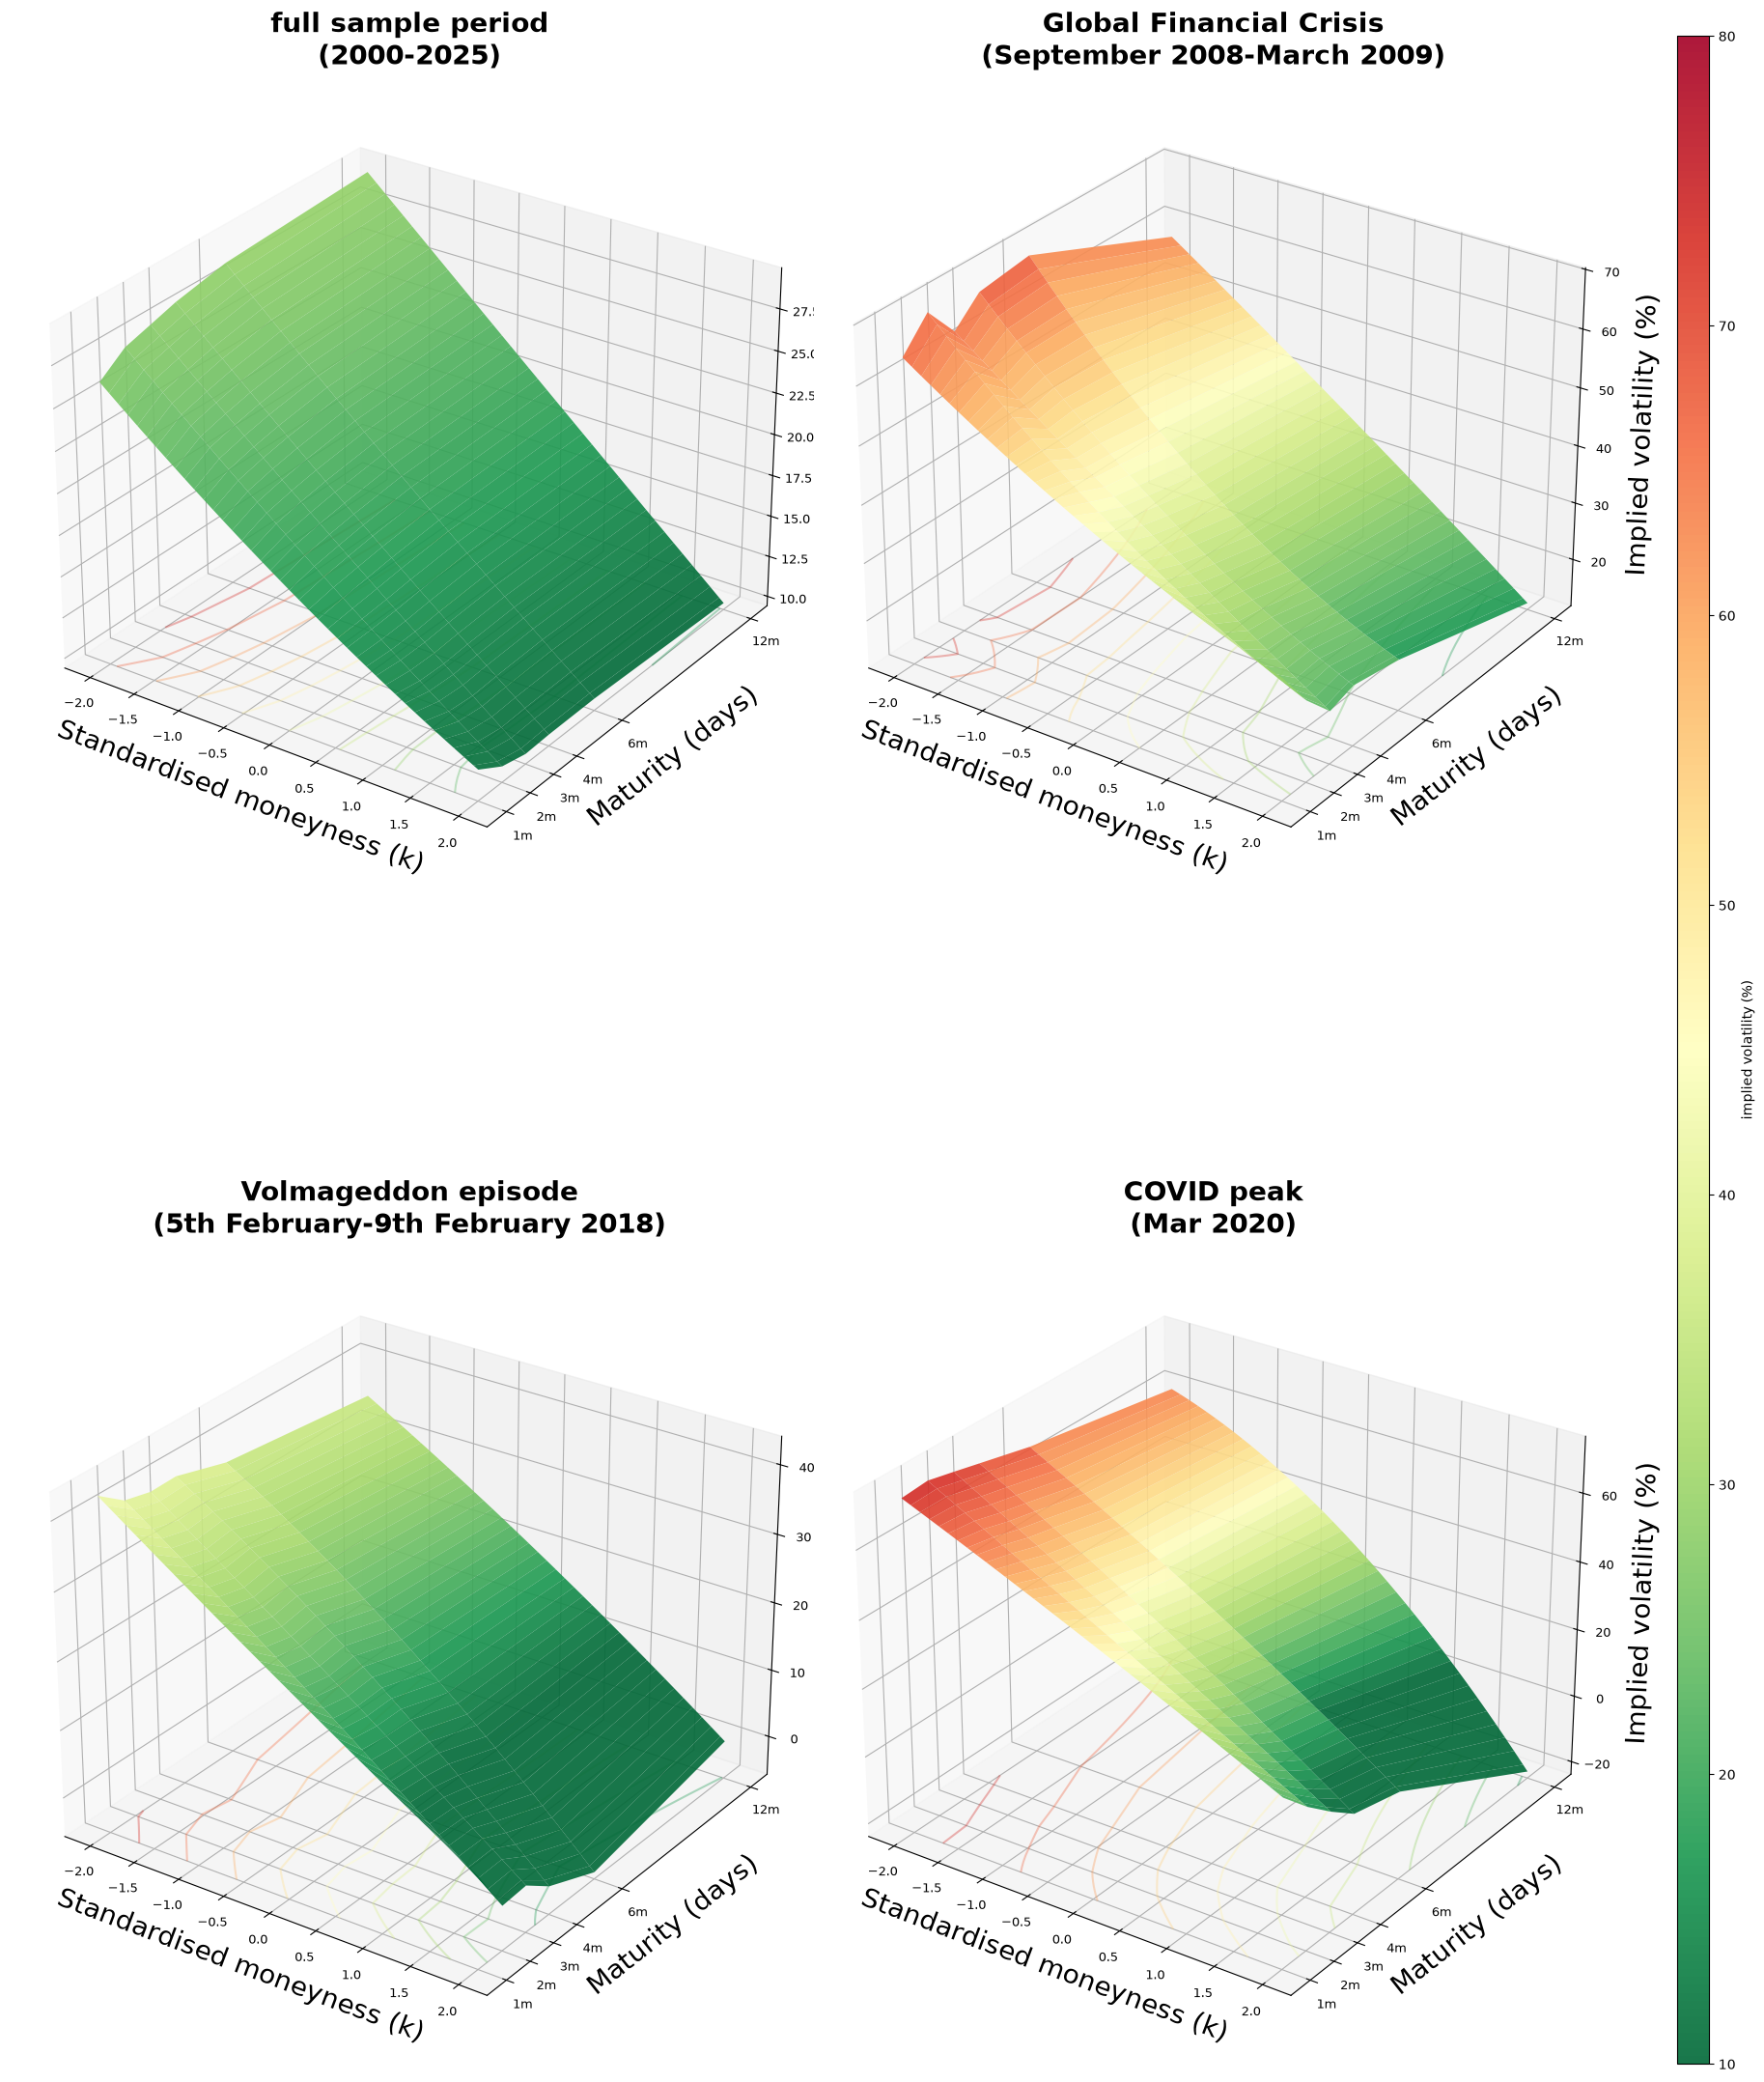

In [15]:
from matplotlib import cm as colormaps
from mpl_toolkits.mplot3d import Axes3D

#each maturity bracket
mat_order = ["1m","2m","3m","4m","6m","12m"]
mat_days = [30,60, 90, 120, 180, 360]

std_grid = np.linspace(-2,2,80)

def recon_smile(gamma0,gamma1,gamma2,std_grid):
    return gamma0+gamma1*std_grid+gamma2*std_grid**2

# constant maturity factors
def surface(cm_factors, date):
    day =cm_factors[cm_factors["date"]==pd.Timestamp(date)]
    iv_matrix = []
    for mat in mat_order:
        row = day[day["maturity"] == mat]
        if row.empty:
            iv_matrix.append(np.full(len(std_grid), np.nan))
        else:
            g0 = float(row["gamma0"].iloc[0])
            g1 = float(row["gamma1"].iloc[0])
            g2 = float(row["gamma2"].iloc[0])
            iv = recon_smile(g0,g1,g2,std_grid)
            iv_matrix.append(iv)
    return np.array(iv_matrix)

def avg_surf(cm_factors, start, end):
    sub = cm_factors[
        (cm_factors["date"] >= pd.Timestamp(start))&
        (cm_factors["date"] <= pd.Timestamp(end))
    ]
    av_param = sub.groupby("maturity")[["gamma0","gamma1","gamma2"]].mean()
    iv_matrix = []
    for mat in mat_order:
        if mat not in av_param.index:
            iv_matrix.append(np.full(len(std_grid), np.nan))
        else:
            g0 = av_param.loc[mat,"gamma0"]
            g1 = av_param.loc[mat,"gamma1"]
            g2 = av_param.loc[mat,"gamma2"]
            iv_matrix.append(recon_smile(g0,g1,g2,std_grid))
    return np.array(iv_matrix)

#possible surface
surfaces = {
    "full sample period\n(2000-2025)": avg_surf(cm_factors,"2000-01-01","2025-07-31"),
    "Global Financial Crisis\n(September 2008-March 2009)": avg_surf(cm_factors, "2008-09-01","2009-03-01"),
    "Volmageddon episode\n(5th February-9th February 2018)": avg_surf(cm_factors,"2018-02-05","2018-02-09"),
    "COVID peak\n(Mar 2020)": avg_surf(cm_factors,"2020-03-16", "2020-04-16"),
}

#mesh
K,M = np.meshgrid(std_grid,mat_days)

fig =plt.figure(figsize=(22,30))

for idex, (title,iv_matrix) in enumerate(surfaces.items(),1):
    axis = fig.add_subplot(2,2,idex, projection="3d")

    surf = axis.plot_surface(
        K,M,iv_matrix*100, cmap="RdYlGn_r",alpha=0.9,linewidth=0,antialiased=True,vmin=10,vmax=80,
    )

    axis.contour(K,M,iv_matrix*100,zdir="z",offset=axis.get_zlim()[0],
                 cmap="RdYlGn_r",alpha=0.35, levels=10)
    
    axis.set_xlabel("Standardised moneyness (k)", labelpad=8, fontsize=20)
    axis.set_ylabel("Maturity (days)", labelpad=8, fontsize=20)
    axis.set_zlabel("Implied volatility (%)", labelpad=8, fontsize=20)
    axis.set_title(title, fontsize=20, fontweight="bold", pad=12)
    axis.set_yticks(mat_days)
    axis.set_yticklabels(["1m","2m","3m","4m","6m","12m"], fontsize=10)
    axis.tick_params(axis="both", labelsize=9)
    axis.view_init(elev=28, azim=-55)

fig.subplots_adjust(right=0.88, hspace = 0.10,wspace=0.005)
colourbar_axis = fig.add_axes([0.91,0.15,0.015,0.7])
fig.colorbar(surf, cax=colourbar_axis, label = "implied volatility (%)")

plt.savefig("S&P500_implied_volatility_quadratic_surface_fit.png")



full sample period:
* the full period surface is on average smooth and gently tilted reflecting an overall calm sample period with a handful of crisis peiods averaged out. 
* the overall elevation is low whereby implied volatility ranges from roughly 10 - 27.5%. 
* geometrically: mild negative slope across the moneyness axis at every maturity - inline with academic literature on the standard equity skew whereby far OTM puts sit above calls.
* surface shows a gentle upward tilt running from front to back along the maturity axis (short dated volatility is lower than long dated volatility)

The full sample surface exhibits a relatively smooth and gently tilted plane with the implied volatility ranging from approximately 10% to 27.5%, as the average over the 25 years of data from 2000 to 2025. This consequently implies that the calm regimes substantially outnumber crisis episodes confirming that contango is the average state over the sample period. Geometrically, the surface displays a mild negative slope across the standardised moneyness axis at each maturity with options at lower standardised moneyness having relatively higher Implied volatility (IV) than those at higher standardised moneyness. This is in line with the standard SPX equity skew whereby the market assigns higher IV to options providing protection against downside risk relative to those with comparable upside exposure reflecting hedging demand for assets with a negative variance risk premium as downside protection. 

The global financial crisis surface deviates substantially from full sample plane in both elevation and shape illustrating that the full sample period acts as a reference plane for average market conditions and obscures conditional regime-specific dynamics. Implied volatility rises to approximately 70% with the peaks more concentrated at shorter maturity with strongly negative standardised moneyness, before declining at longer maturities at less negative moneyness. From this elevated corner, the surface falls steeply in two directions namely, toward less negative and positive standardised moneyness, consistent with demand for downside protection and crash-risk pricing (Ahmed, 2026; Li and Zinna, 2015), and toward longer maturities as it slopes downward representing an inverse relationship of contango in the sample period toward backwardation. This pattern is consistent with the mean-reverting dynamics documented by Mixon (2007), whereby short-dated IV reacts to current prevailing conditions while long-dated IV remains comparatively stable consistent with the assumption that it will later converge towards the long-end. A similar mean-reverting dynamic is present in the COVID-19 surface with similar concentration of IV at short-dated maturity options than long dated options. 

In comparison to the two crisis periods, the volmageddon episode is notable modest in absolute elevation with IV peaking at approximately 40%, concentrated at short-dated options, compared to the 70 – 80 % range observed during the global financial crisis and COVID-19. Though, according to Augustin et al. (2021), this period is associated with the abrupt market crash of short volatility strategies on 5th February 2018, as the implied volatility surface represents average constant maturity factors whereby we linearly interpolate maturities closest to set bracket maturities, the spike in realised and implied volatility was concentrated within a single trading session before partially mean-reverting resulting in the five-day period attenuating the peak-day distortion


In [22]:
tS = cm_factors.pivot_table(index="date", columns="maturity", values="gamma0")[mat_order]*100
tS

maturity,1m,2m,3m,4m,6m,12m
date,,,,,,
2000-01-03,22.050080,22.361645,22.655750,22.601413,22.483805,21.528353
2000-01-04,25.315092,24.048518,23.792887,23.682914,23.438428,22.847298
2000-01-05,24.336410,23.902330,24.045870,23.980591,23.807719,22.875363
2000-01-06,23.942410,23.702743,24.143156,24.305611,24.341422,22.494052
2000-01-07,19.587794,20.289293,20.820526,21.095086,21.491473,21.866091
...,...,...,...,...,...,...
2025-07-25,12.632866,13.798390,14.420747,15.072550,15.473358,17.013207
2025-07-28,12.742138,13.719364,14.238354,14.790183,15.424142,16.962245
2025-07-29,13.577235,14.175594,14.633617,14.942071,15.591977,17.140480


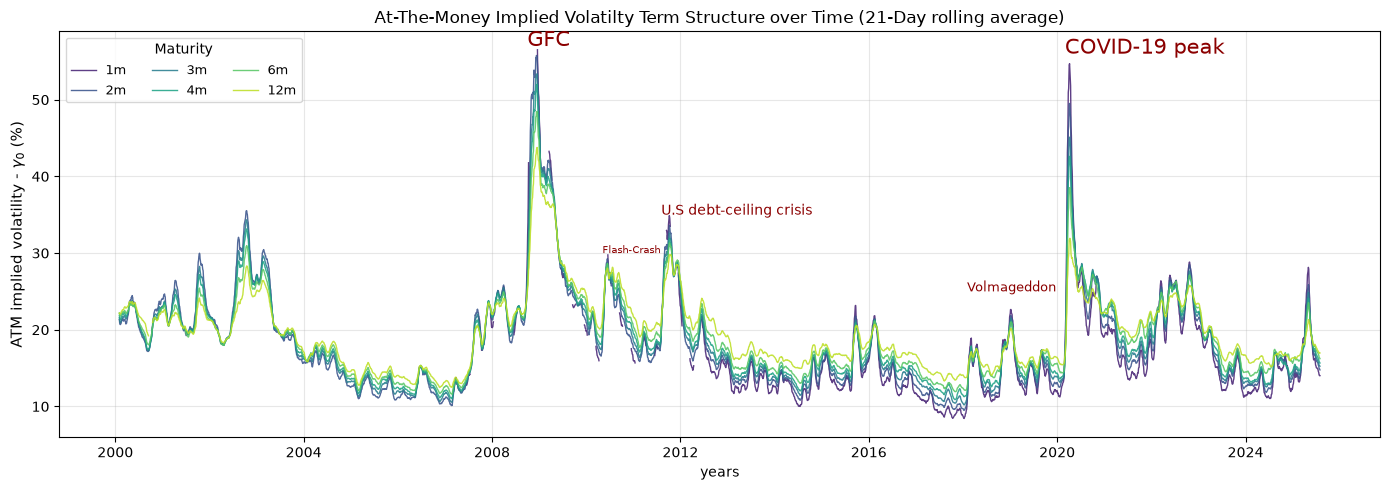

In [20]:
figure, axis = plt.subplots(figsize = (14,5))
colours = plt.cm.viridis(np.linspace(0.1,0.9,6))

#derive the atm term structure 
Atm_TS = cm_factors.pivot_table(index="date", columns="maturity", values="gamma0")[mat_order]*100

for i, mat in enumerate(mat_order):
    axis.plot(
        Atm_TS.index,
        Atm_TS[mat].rolling(21).mean(),
        color=colours[i], linewidth=1.0, label=mat, alpha=0.88,
    )
axis.set_ylabel("ATM implied volatility - $\\gamma_0$ (%)", fontsize=11)
axis.set_xlabel("years", fontsize=10)
axis.set_title("At-The-Money Implied Volatilty Term Structure over Time (21-Day rolling average)")
axis.legend(title="Maturity", fontsize=9,ncol=3,loc="upper left")
axis.grid(alpha=0.3)



#annotating key regimes
#volmageddon episode, covid 19 period, great financial crisis, Flash-crash, U.S debt-ceiling crisis
axis.annotate("GFC", xy=(pd.Timestamp("2008-10-01"),57), fontsize=15,color="darkred")
axis.annotate("COVID-19 peak", xy=(pd.Timestamp("2020-03-01"),56), fontsize=15,color="darkred")
axis.annotate("Flash-Crash",xy=(pd.Timestamp("2010-05-06"),30), fontsize=7,color="darkred")
axis.annotate("U.S debt-ceiling crisis",xy=(pd.Timestamp("2011-08-05"),35),fontsize=10,color="darkred")
axis.annotate("Volmageddon",xy=(pd.Timestamp("2018-02-01"),25),fontsize=9,color="darkred")
plt.tight_layout()
plt.show()



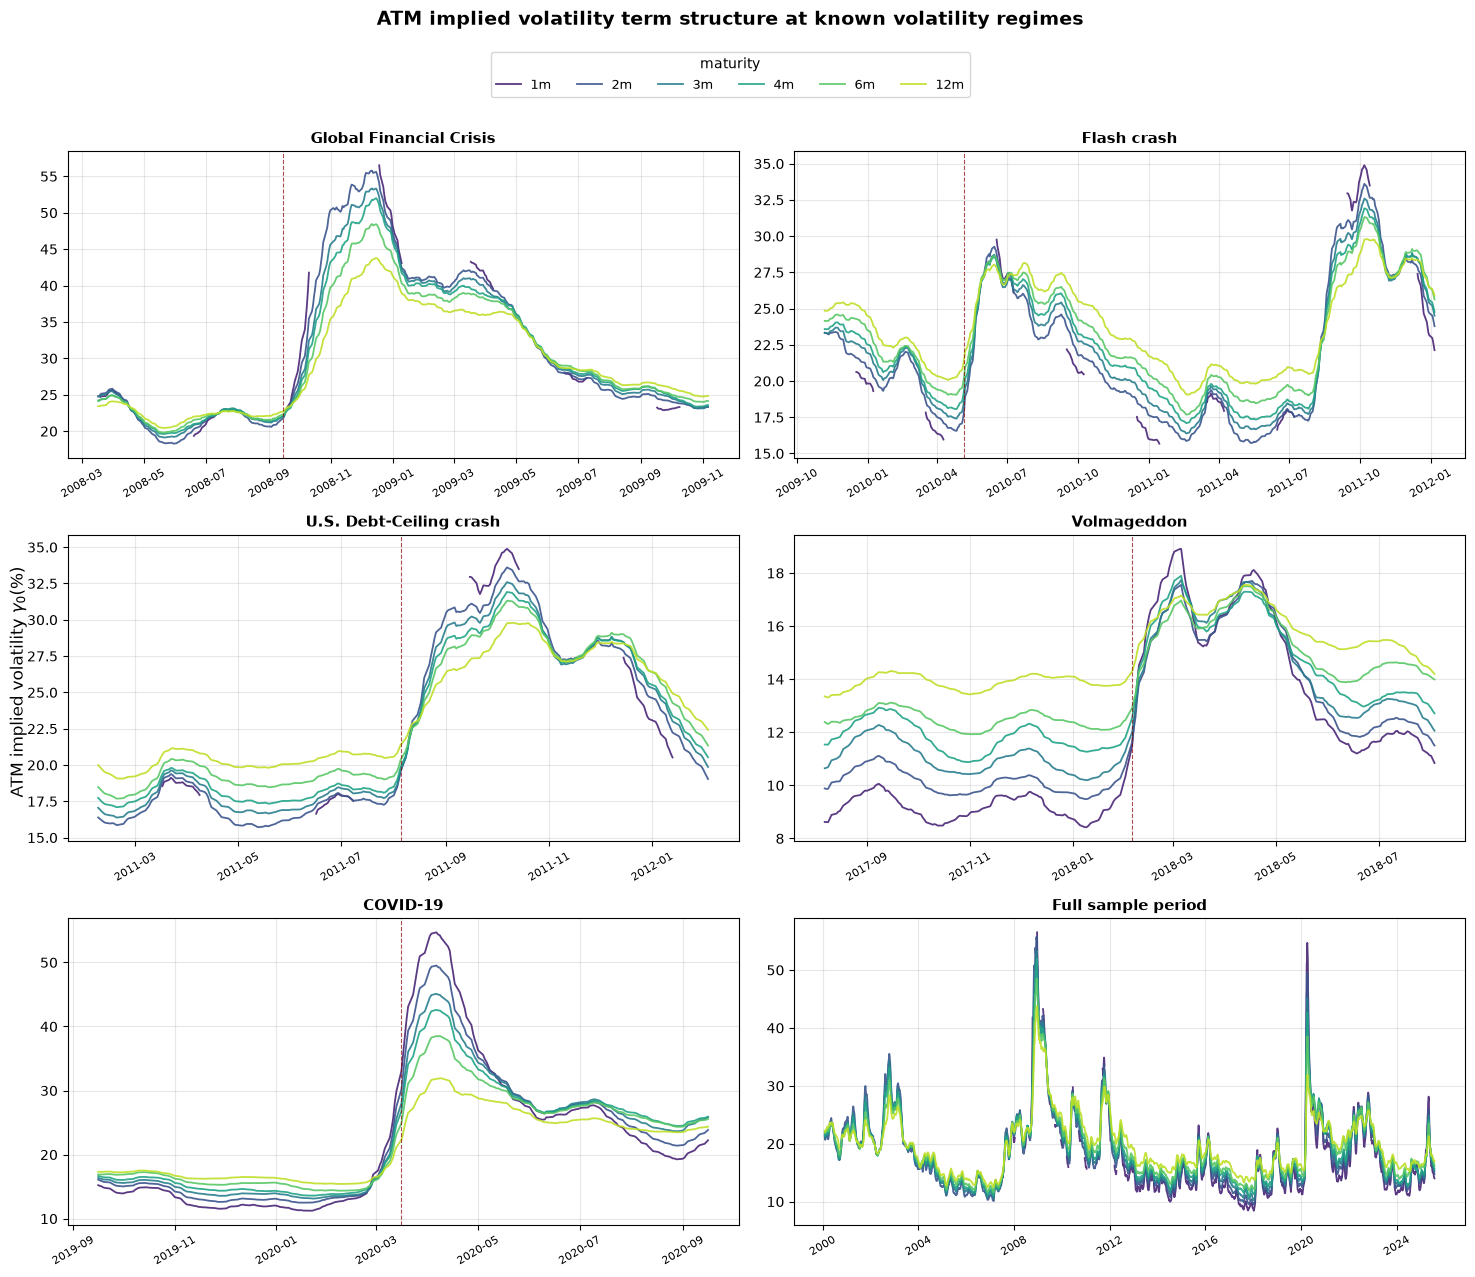

In [24]:
#plot for each event
ATM_rolling = Atm_TS.rolling(21).mean()

#define each episode
events = {
    "Global Financial Crisis": {
        "date":"2008-09-15",
        "start":"2008-03-15",
        "end":"2009-11-06"
    },
    "Flash crash":{
        "date":"2010-05-06",
        "start":"2009-11-06",
        "end":"2012-01-06"
    },
    "U.S. Debt-Ceiling crash":{
        "date":"2011-08-05",
        "start":"2011-02-05",
        "end":"2012-02-05",
    },
    "Volmageddon":{
        "date":"2018-02-05",
        "start":"2017-08-05",
        "end":"2018-08-05"
    },
    "COVID-19":{
        "date":"2020-03-16",
        "start":"2019-09-16",
        "end":"2020-09-16",
    },
    "Full sample period": {
    "date": None,  
    "start" :"2000-01-01",
    "end":"2025-07-31",
    },                                                  
}

fig, axis = plt.subplots(3,2,figsize=(15,12))
axis = axis.flatten()

for i, (event_name,info) in enumerate(events.items()):
    ax = axis[i]

    start = pd.Timestamp(info["start"])
    end=pd.Timestamp(info["end"])
    event_date = pd.Timestamp(info["date"]) if info["date"] is not None else None

    event_data = ATM_rolling.loc[start:end]

    for j, mat in enumerate(mat_order):
        ax.plot(event_data.index, event_data[mat], color=colours[j],linewidth=1.3,label=mat,alpha=0.9)
    
    if info["date"] is not None:
        ax.axvline(pd.Timestamp(info["date"]), color="darkred",linestyle="--",linewidth=0.8, alpha=0.7)

    ax.set_title(event_name,fontsize=11,fontweight="bold")
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)

hand, labels=axis[0].get_legend_handles_labels()
fig.legend(hand,labels,title="maturity",loc="upper center",ncol = 6,fontsize=9, bbox_to_anchor=(0.5,1.03))
fig.supylabel("ATM implied volatility $\\gamma_0$(%)")
fig.suptitle("ATM implied volatility term structure at known volatility regimes", fontsize=14,fontweight="bold",y=1.06)
plt.tight_layout()
plt.savefig("ATM implied volatility term structure at known volatility regimes.png")

In [220]:
events

{'Global Financial Crisis': {'date': '2008-09-15',
  'start': '2008-03-15',
  'end': '2019-11-06'},
 'Flash crash': {'date': '2010-05-06',
  'start': '2009-11-06',
  'end': '2012-11-06'},
 'U.S. Debt-Ceiling crash': {'date': '2011-08-05',
  'start': '2011-02-05',
  'end': '2012-02-05'},
 'Volmageddon': {'date': '2018-02-05',
  'start': '2017-08-05',
  'end': '2018-08-05'},
 'COVID-19': {'date': '2020-03-16',
  'start': '2019-09-16',
  'end': '2020-09-16'}}

In [172]:
Atm_TS

maturity,1m,2m,3m,4m,6m,12m
date,,,,,,
2000-01-03,22.050080,22.361645,22.655750,22.601413,22.483805,21.528353
2000-01-04,25.315092,24.048518,23.792887,23.682914,23.438428,22.847298
2000-01-05,24.336410,23.902330,24.045870,23.980591,23.807719,22.875363
2000-01-06,23.942410,23.702743,24.143156,24.305611,24.341422,22.494052
2000-01-07,19.587794,20.289293,20.820526,21.095086,21.491473,21.866091
...,...,...,...,...,...,...
2025-07-25,12.632866,13.798390,14.420747,15.072550,15.473358,17.013207
2025-07-28,12.742138,13.719364,14.238354,14.790183,15.424142,16.962245
2025-07-29,13.577235,14.175594,14.633617,14.942071,15.591977,17.140480


## constant maturity IV curve dynamics

### term spread dynamics

#### data

In [18]:
spreads = pd.read_csv("term_spreads_data.csv")
spreads["date"] = pd.to_datetime(spreads["date"])
spreads.sample(20)

,date,factor,long_maturity,short_maturity,spread,spread_label
38223,2002-02-14,gamma2,12m,6m,0.000112,gamma2__12m__6m
37910,2001-08-24,gamma2,6m,1m,0.001464,gamma2__6m__1m
41273,2006-09-05,gamma2,12m,1m,-0.003130,gamma2__12m__1m
46219,2013-08-27,gamma2,12m,1m,-0.001380,gamma2__12m__1m
26187,2011-06-14,gamma1,12m,1m,-0.017146,gamma1__12m__1m
17844,2024-10-29,gamma0,12m,6m,0.003559,gamma0__12m__6m
11530,2016-06-20,gamma0,6m,1m,0.016184,gamma0__6m__1m
48450,2016-08-10,gamma2,6m,1m,-0.001349,gamma2__6m__1m
37544,2001-02-01,gamma2,12m,6m,0.001061,gamma2__12m__6m
40489,2005-07-05,gamma2,12m,6m,-0.000936,gamma2__12m__6m


In [19]:
spreads.info()

<class 'pandas.DataFrame'>
RangeIndex: 55218 entries, 0 to 55217
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            55218 non-null  datetime64[us]
 1   factor          55218 non-null  str           
 2   long_maturity   55218 non-null  str           
 3   short_maturity  55218 non-null  str           
 4   spread          55218 non-null  float64       
 5   spread_label    55218 non-null  str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 3.9 MB


#### time series of level term spreads

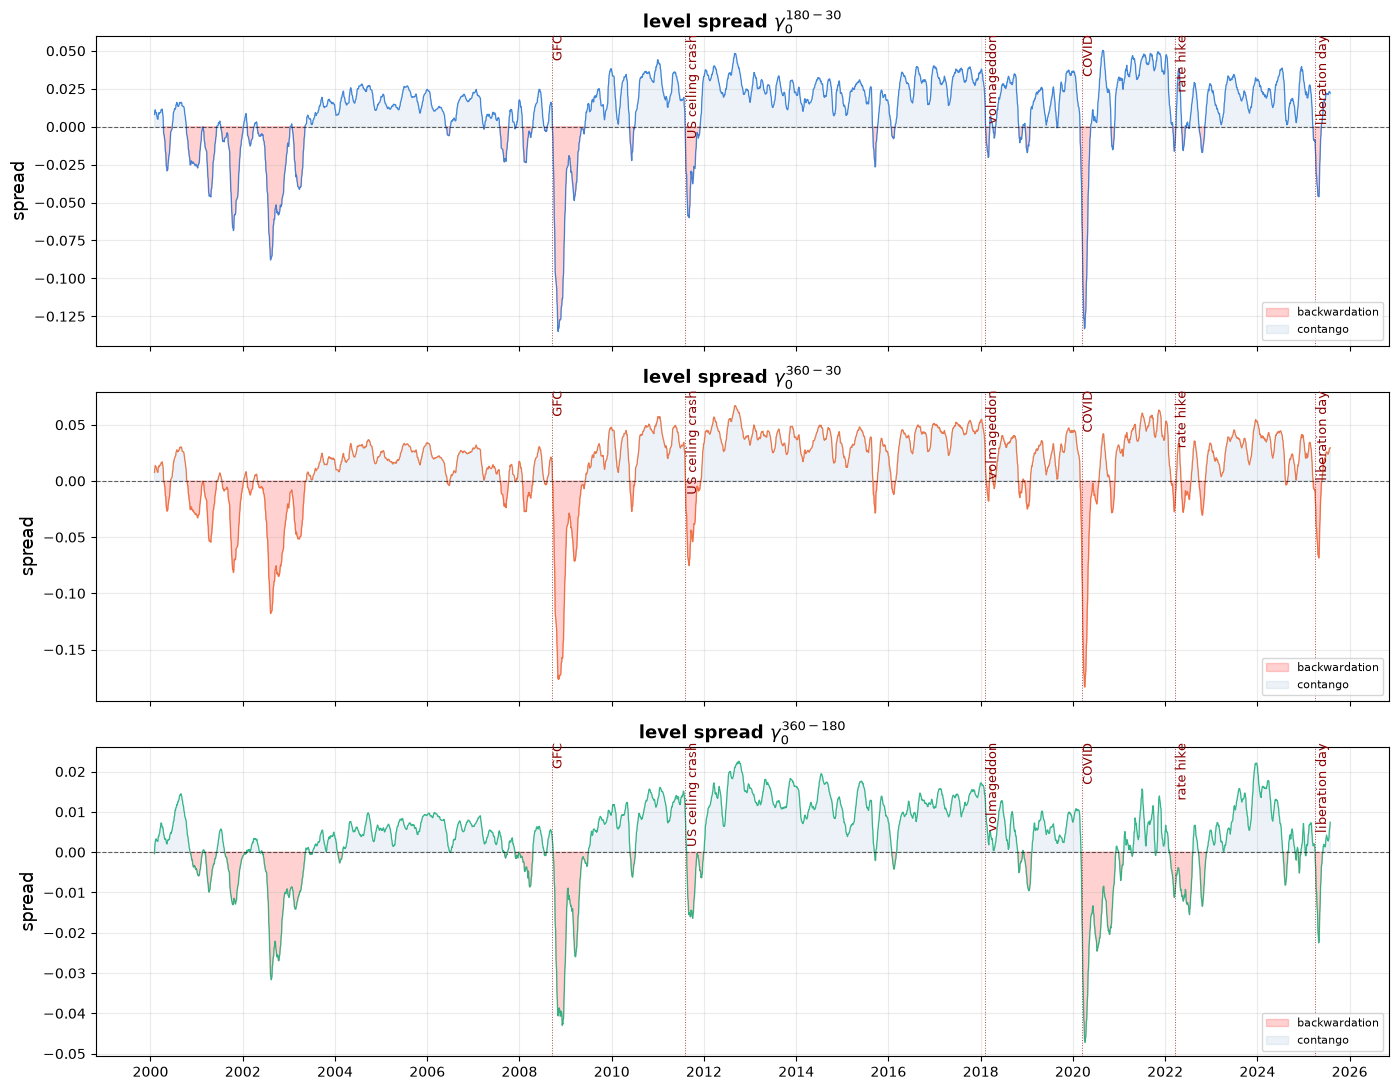

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

figure, axis = plt.subplots(3,1, figsize=(14,11), sharex=True)



term_pairs = [
    ("gamma0__6m__1m",  "level spread $\\gamma_0^{180-30}$","#2a78d6"),
    ("gamma0__12m__1m", "level spread $\\gamma_0^{360-30}$","#eb6835"),
    ("gamma0__12m__6m", "level spread $\\gamma_0^{360-180}$","#1baf7a"),
]

for ax, (label, title, colour) in zip(axis, term_pairs):
    series = (spreads[spreads["spread_label"] ==label].set_index("date")["spread"].sort_index())

    #21-day rolling average
    rolled = series.rolling(21).mean()

    ax.plot(rolled.index, rolled, color=colour, linewidth=0.9, alpha=0.88)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

    #backwardation periods
    ax.fill_between(rolled.index,rolled, 0, where=(rolled<0),color="red", alpha=0.18, label="backwardation")
    ax.fill_between(rolled.index, rolled,0, where=(rolled>=0), color="steelblue",alpha=0.10, label="contango")

    #known events
    for event, date in [("GFC","2008-09-15"),("COVID","2020-03-16"),
                        ("US ceiling crash","2011-08-05"),
                        ("volmageddon","2018-02-05"),
                        ("rate hike","2022-03-16"),
                        ("liberation day","2025-04-02")]:
        ax.axvline(pd.Timestamp(date), color="darkred", linewidth=0.7, linestyle=":",alpha=0.7)
        ax.text(pd.Timestamp(date),rolled.max()*1.2, event, fontsize=9, color="darkred", rotation=90, va="top")
    
    ax.set_ylabel("spread",fontsize=13)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))


plt.tight_layout()
plt.savefig("time_soread_timeseries.png")
plt.show()


rate high resulted in more prolonged negative spread than the toher level spreads

* overall aggrees with the assumption that the market is in contango on average with spikes leading to backwardation.

* 180-30 spead:
majority within a 0.00 to 0.05 band
during backwardation, spread reaches < - 0.125. 
known volatility shock events fall into backwardation periods. 
short-dated ATM IV greater than long ATM IV during crisis periods.
covid and gfc had relatively similar levels of negative spreads. 



#### summary statistics

In [90]:
from scipy.stats import skew, kurtosis

Mat_pairs = [
    ("gamma0__6m__1m",  "gamma_0^{180-30}"),
    ("gamma0__12m__1m", "gamma_0^{360-30}"),
    ("gamma0__12m__6m", "gamma_0^{360-180}"),
    ("gamma1__6m__1m",  "gamma_1^{180-30}"),
    ("gamma1__12m__1m", "gamma_1^{360-30}"),
    ("gamma1__12m__6m", "gamma_1^{360-180}"),
    ("gamma2__6m__1m",  "gamma_2^{180-30}"),
    ("gamma2__12m__1m", "gamma_2^{360-30}"),
    ("gamma2__12m__6m", "gamma_2^{360-180}"),
]
rows = []

for label, variable in Mat_pairs:
    s = (spreads[spreads["spread_label"]==label].set_index("date")["spread"].sort_index().dropna())

    ar1 = s.autocorr(1)
    perct_back = (s <0).mean()*100

    rows.append({
        "spread": variable,
        "mean": round(s.mean(),3),
        "Std": round(s.std(),3),
        "Min": round(s.min(),3),
        "Max": round(s.max(),3),
        "Skewness": round(skew(s),3),
        "kurtosis": round(kurtosis(s),3),
        "AR(1)": round(ar1, 3),
        "% B": round(perct_back,2)
    })
spread_table = pd.DataFrame(rows)
spread_table

,spread,mean,Std,Min,Max,Skewness,kurtosis,AR(1),% B
0,gamma_0^{180-30},0.012,0.029,-0.146,0.055,-2.196,7.442,0.944,21.78
1,gamma_0^{360-30},0.016,0.038,-0.199,0.068,-2.281,7.862,0.954,22.42
2,gamma_0^{360-180},0.004,0.011,-0.048,0.024,-1.522,3.753,0.964,26.97
3,gamma_1^{180-30},-0.010,0.009,-0.047,0.009,-0.972,2.191,0.851,89.73
4,gamma_1^{360-30},-0.012,0.011,-0.072,0.015,-1.421,5.419,0.893,90.01
5,gamma_1^{360-180},-0.002,0.007,-0.048,0.029,-1.162,10.763,0.806,66.93
6,gamma_2^{180-30},-0.001,0.003,-0.011,0.018,2.426,14.811,0.800,84.33
7,gamma_2^{360-30},-0.002,0.005,-0.023,0.034,2.562,25.645,0.803,87.31
8,gamma_2^{360-180},-0.001,0.005,-0.042,0.033,-1.914,33.519,0.739,65.22


In [91]:
spread_table.to_csv("term_spread_dynamics_table.csv", index=False)

### hump spread dynamics

#### regime conditional hump factor statistics

In [78]:
humps = hump_factor(cm_factors)
humps.head()

,date,factor,hump_value,mid_maturity,short_maturity,long_maturity
0,2000-01-03,gamma0,-0.000082,6m,1m,12m
1,2000-01-04,gamma0,0.000092,6m,1m,12m
2,2000-01-05,gamma0,-0.000017,6m,1m,12m
3,2000-01-06,gamma0,-0.000129,6m,1m,12m
4,2000-01-07,gamma0,-0.000106,6m,1m,12m


In [83]:
# recall investigating whether hump factor provides additional information
# regime signal: during backwardation 
from scipy.stats import ttest_ind

signal_back = (spreads[spreads["spread_label"]=="gamma0__6m__1m"].set_index("date")["spread"])
Dt = (signal_back < 0).rename("backwardation")

rows = []
for fact, display  in [("gamma0","$H_0$"), ("gamma1","$H_1$"),
                       ("gamma2","H_2$")]:
    h = (humps[humps["factor"] == fact].set_index("date")["hump_value"].dropna())
    merged = pd.DataFrame({"hump":h}).join(Dt,how="inner").dropna()

    contango = merged[merged["backwardation"] ==0]["hump"]
    backwardation = merged[merged["backwardation"] ==1]["hump"]

    t_stat, p_val = ttest_ind(contango, backwardation, equal_var=False)
    rows.append({
        "hump": display,
        "H_mean": round(h.mean(),6),
        "H_std": round(h.std(), 6),
        "AR(1)": round(h.autocorr(1), 6),
        "contango mean": round(contango.mean(),6),
        "backwardation mean": round(backwardation.mean(),6),
        "Difference (B-C)": round(backwardation.mean()-contango.mean(),6),
        "t-Statistic": round(t_stat, 4),
        "p-value": round(p_val, 4),
    })
hump_table = pd.DataFrame(rows)
hump_table


,hump,H_mean,H_std,AR(1),contango mean,backwardation mean,Difference (B-C),t-Statistic,p-value
0,$H_0$,-0.000057,0.000149,0.926108,-0.000114,0.000146,0.000260,-56.2809,0.0
1,$H_1$,0.000052,0.000072,0.796645,0.000045,0.000075,0.000030,-9.4341,0.0
2,H_2$,0.000007,0.000038,0.770503,0.000009,-0.000004,-0.000013,6.4021,0.0


#### time series

## regression analysis

In [151]:
from regression_analysis import (regime_indicator,run_full_analysis)

In [152]:
## spot check
lvl_sprd_180_30 = (spreads[spreads["spread_label"]=="gamma0__6m__1m"].set_index("date")["spread"])

D_t = regime_indicator(lvl_sprd_180_30)

regime_dataframe = pd.DataFrame({
    "spread": lvl_sprd_180_30,
    "backwardation": D_t,
})
regime_dataframe["year"] = regime_dataframe.index.year

print(regime_dataframe.groupby("year")["backwardation"].mean())
stress = {
    "GFC peak":     ("2008-09-01","2008-11-30"),
    "covid crash":  ("2020-03-01","2020-04-30"),
}

for lable, (start,end) in stress.items():
    rate = D_t.loc[start:end].mean()
    print(f"{lable}:{rate:.1}%")

year
2000    0.449761
2001    0.824390
2002    0.778846
2003    0.304762
2004    0.039024
2005    0.004762
2006    0.100000
2007    0.277533
2008    0.556561
2009    0.400901
2010    0.147982
2011    0.308696
2012    0.000000
2013    0.023810
2014    0.039683
2015    0.138889
2016    0.103175
2017    0.007968
2018    0.298805
2019    0.075397
2020    0.304348
2021    0.011905
2022    0.330677
2023    0.032000
2024    0.075397
2025    0.298611
Name: backwardation, dtype: float64
GFC peak:0.9%
covid crash:1e+00%


In [155]:
import regression_analysis
importlib.reload(regression_analysis)

from regression_analysis import run_full_analysis

# 3.5 Regime-Conditional Regression Analysis

---

## 3.5.1 Baseline Regression Framework

The baseline regression analysis developed by Guo et al. (2023) investigated whether the shape of the implied volatility term structure could predict variance-sensitive asset returns by imposing a single, time-invariant coefficient $\beta$:

$$R_{t:t+1} = \alpha + \beta X_t + \epsilon_{t:t+1} \tag{11}$$

where $t = 1, 2, \ldots, T-1$, $R_{t:t+1}$ is the next-day, next-week, or next-month asset return, and $X_t$ is the level, slope, or curvature term spread.

This specification assumes a **constant** relationship between each predictor and subsequent returns across the full sample period. A positive term spread signals that investors expect future volatility to rise, prompting increased demand for variance-hedging instruments. This bids up the price of those instruments, leading to negative returns for buyers of variance-sensitive assets — the mechanism underlying the negative variance risk premium.

### Economic Interpretation: Contango and Backwardation

**Contango** $(X_t > 0)$: The market prices calm current conditions but expects greater uncertainty in the future, producing an upward-sloping IV curve across maturities. Mixon (2007) documents that short-dated IV reacts sensitively to prevailing conditions while long-dated IV remains comparatively stable, reflecting expectations of volatility converging toward its long-run level. Buyers of variance protection systematically overpay relative to subsequently realised volatility — the VRP is negative from the buyer's perspective and positive from the seller's perspective.

**Backwardation** $(X_t < 0)$: Short-dated IV exceeds long-dated IV, producing a downward-sloping curve. The market is already stressed but expects conditions to normalise over the long run, consistent with the mean-reverting dynamics of variance documented by Zhang, Shu and Brenner (2010). Hedging demand is front-loaded rather than anticipated — investors seek immediate protection rather than pricing in future rises.

### Regime-Conditional Indicator

To formalise the distinction between these two states, we introduce a binary regime indicator:

$$D_t = \begin{cases} 1 & \text{negative term spread (backwardation)} \\ 0 & \text{positive term spread (contango)} \end{cases} \tag{12}$$

---

## 3.5.2 In-Sample Analysis

We formulate the following regime-conditional regression to examine whether the implied volatility factors predict variance-sensitive returns across different maturities:

$$R_{t:t+1} = \alpha + \beta_1 X_t + \beta_2 D_t + \beta_3 X_t D_t + \epsilon_{t:t+1} \tag{13}$$

where $D_t$ is the regime indicator, $R_{t:t+1}$ is the next-day, next-week, or next-month asset return, and $X_t$ is the level, slope, or curvature term spread or hump factor for each separate regression.

### Regression Horizon and Standard Errors

We run **overlapping regressions** at each horizon:

| Horizon | Construction |
|---------|-------------|
| Next-day | Raw daily return at $t+1$ |
| Next-week | Compounded daily returns from $t+1$ to $t+5$ (Monday–Friday) |
| Next-month | Compounded daily returns from $t+1$ to $t+21$ (four trading weeks) |

Standard errors are adjusted using **Newey-West HAC estimators** (Newey and West, 1987) with lag lengths chosen to match the compounding window:
- **4 lags** for weekly returns
- **20 lags** for monthly returns

This ensures hypothesis testing remains asymptotically valid in the presence of heteroscedasticity and autocorrelation induced by overlapping return windows. A coefficient is considered statistically significant at **$p < 0.05$** using a **two-tailed test** comparing the Newey-West adjusted $t$-statistic against the standard normal distribution.

### Regime-Specific Coefficient Interpretation

**Table 2: Interpretation of linear regression coefficients**

| Regime | Intercept | Slope on $X_t$ |
|--------|-----------|----------------|
| Contango $(D_t = 0)$ | $\alpha$ | $\beta_1$ |
| Backwardation $(D_t = 1)$ | $\alpha + \beta_2$ | $\beta_1 + \beta_3$ |

*Table 2 reports the regime-specific parameters within the in-sample regression. In contango ($D_t = 0$), the intercept and slope are given directly by $\alpha$ and $\beta_1$. In backwardation ($D_t = 1$), the effective intercept becomes $\alpha + \beta_2$ and the effective slope becomes $\beta_1 + \beta_3$.*

The individual coefficients carry the following interpretations:

- $\beta_2$ — **intercept shift**: indicates whether the average level of returns differs across regimes independently of the spread value.
- $\beta_3$ — **slope shift**: indicates whether a one-unit change in the spread moves returns by a different amount depending on regime.

A statistically significant $\beta_3$ indicates the predictive relationship is **not** a single global monotonic effect but differs meaningfully in strength — and potentially in sign — across regimes:

$$\text{If } \beta_3 < 0 \text{ and } \beta_1 < 0 \Rightarrow \text{backwardation slope more negative } \Rightarrow \text{stronger negative VRP during stress}$$

$$\text{If } \beta_3 > 0 \text{ and } |\beta_3| > |\beta_1| \Rightarrow \beta_1 + \beta_3 > 0 \Rightarrow \text{sign reversal in backwardation}$$

---

## 3.5.3 Out-of-Sample Analysis

### Sample Partition

The full 2000–2025 sample is partitioned as follows:

| Period | Dates | Length |
|--------|-------|--------|
| In-sample estimation | January 2000 – December 2015 | 15 years |
| Out-of-sample evaluation | January 2016 – July 2025 | ~10 years |

This follows the conventional **60/40 temporal split** applied in the return predictability literature (Campbell and Thompson, 2008). The split point is fixed prior to model estimation to preclude look-ahead bias.

The out-of-sample period encompasses at least three structurally distinct volatility regimes:
- **2016–2019**: Low-volatility expansion
- **5 February 2018**: Volmageddon — abrupt collapse of short-volatility products (Augustin et al., 2021)
- **March 2020**: COVID-19 volatility shock
- **2022**: Federal Reserve monetary tightening cycle and rate-driven bear market

### OOS Forecast Generation

In-sample coefficients estimated on 2000–2015 data are held **fixed** and applied to out-of-sample observations of $X_t$ and $D_t$:

$$\hat{R}_{t:t+1} = \hat{\alpha} + \widehat{\beta_1} X_t + \widehat{\beta_2} D_t + \widehat{\beta_3} X_t D_t \tag{14}$$

where $\hat{\alpha}, \widehat{\beta_1}, \widehat{\beta_2}, \widehat{\beta_3}$ are fixed from the 2000–2015 in-sample regression, and $\hat{R}_{t:t+1}$ is the predicted return using those fixed coefficients.

### Evaluation Metric 1 — Campbell-Thompson $R^2_{OS}$

The primary OOS evaluation metric follows Campbell and Thompson (2008):

$$R^2_{OS} = 1 - \frac{\displaystyle\sum_{t=t_0}^{t_n} \left(R_{t+1} - \hat{R}_{t+1|t}\right)^2}{\displaystyle\sum_{t=t_0}^{t_n} \left(R_{t+1} - \bar{R}_{IS}\right)^2} \tag{15}$$

where $R_{t+1}$ is the realised return, $\hat{R}_{t+1|t}$ is the model's one-period-ahead forecast, and $\bar{R}_{IS}$ is the in-sample historical mean (held constant as the benchmark).

$$R^2_{OS} > 0 \Rightarrow \text{model beats the historical mean benchmark}$$
$$R^2_{OS} < 0 \Rightarrow \text{model is outperformed by the historical mean}$$

### Evaluation Metric 2 — Clark-West MSPE-Adjusted Statistic

Since we compare a **restricted** model (historical mean) against a **nested unrestricted** model (regression), the standard Diebold-Mariano test is biased against finding predictability. We apply the Clark-West (2007) MSPE-adjusted statistic to correct for this:

$$\mathcal{F}_{t+1} = \left(R_{t+1} - \bar{R}_{IS}\right)^2 - \left[\left(R_{t+1} - \hat{R}_{t+1|t}\right)^2 - \left(\bar{R}_{IS} - \hat{R}_{t+1|t}\right)^2\right] \tag{16}$$

We compute $\bar{\mathcal{F}} = T^{-1} \sum_t \mathcal{F}_{t+1}$ and test whether it is **significantly positive** using the $t$-statistic from regressing $\mathcal{F}_{t+1}$ on a constant with Newey-West standard errors. The test is **one-tailed** since the alternative hypothesis is directional — the factor model beats the benchmark.

### Evaluation Metric 3 — Directional Accuracy (DA)

As an additional metric, we report the **directional accuracy** (DA): the proportion of out-of-sample periods in which the predicted sign of the return matches the realised sign.

$$DA = \frac{1}{T_{OOS}} \sum_{t=t_0}^{t_n} \mathbf{1}\left[\text{sign}(\hat{R}_{t+1}) = \text{sign}(R_{t+1})\right]$$

Significance is assessed using a **one-sided binomial test** against the null of 50% hit rate ($H_0: DA = 0.50$, $H_1: DA > 0.50$), evaluated on non-overlapping weekly and monthly observations to avoid size distortion from serially correlated sign predictions.

---

> **Note:** All regression computations are implemented in `regression_analysis.py`. The `run_full_analysis()` function loops over all (asset × maturity × horizon × predictor) combinations and returns a single results DataFrame containing both in-sample and out-of-sample metrics for each specification.

In [156]:
results = run_full_analysis(
    vrp_panel=vrp_panel,
    term_spreads= spreads,
    hump_factors=humps,
    train_end="2015-12-31",
)
results.to_csv("overall_study_results.csv",index=False)



In [157]:
results


,asset,maturity,horizon,predictor,is_alpha,is_beta1,is_beta2,is_beta3,is_t_alpha,is_t_beta1,...,r2_out_of_sample,clark-west_statistic,clark-west_p_value,directional_accuracy,directional_accuracy_n_correct,directional_accuracy_n_total,directional_accuracy_p_value,error present,N_is,N_obs
0,variance_swap,12m,daily,gamma0__12m__1m,-0.000410,-0.001361,0.001592,0.014573,-0.211554,-0.020933,...,-0.000490,-0.467489,0.679925,0.544575,1069.0,1963.0,0.000043,NaN,NaN,NaN
1,variance_swap,12m,daily,gamma0__12m__6m,-0.001363,0.100644,0.000463,-0.231169,-0.883723,0.576253,...,-0.002858,-1.317575,0.906177,0.535914,1052.0,1963.0,0.000786,NaN,NaN,NaN
2,variance_swap,12m,daily,gamma0__6m__1m,-0.000853,0.024143,0.002175,-0.000325,-0.465204,0.279910,...,-0.000073,0.107916,0.457031,0.545593,1071.0,1963.0,0.000029,NaN,NaN,NaN
3,variance_swap,12m,daily,gamma1__12m__1m,0.010274,-2.226865,-0.007846,2.406976,1.373218,-1.568716,...,-0.009773,0.536719,0.295731,0.481915,946.0,1963.0,0.947938,NaN,NaN,NaN
4,variance_swap,12m,daily,gamma1__12m__6m,0.000935,0.336077,-0.001559,-0.268049,0.429477,0.750280,...,0.002276,1.463869,0.071615,0.525217,1031.0,1963.0,0.013474,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,straddle,6m,monthly,gamma2__12m__6m,-0.018028,4.243960,-0.012851,-5.602658,-2.325269,2.255155,...,0.079601,1.159503,0.123126,0.562500,27.0,48.0,0.235440,NaN,NaN,NaN
404,straddle,6m,monthly,gamma2__6m__1m,-0.019817,5.404570,0.009556,0.273645,-1.419457,1.688296,...,-0.006095,0.103468,0.458796,0.541667,26.0,48.0,0.332733,NaN,NaN,NaN
405,straddle,6m,monthly,hump_gamma0,-0.029799,174.616478,0.028388,125.596847,-2.976946,2.419964,...,-0.057795,0.441631,0.329378,0.541667,26.0,48.0,0.332733,NaN,NaN,NaN
406,straddle,6m,monthly,hump_gamma1,-0.017950,-46.579339,-0.013505,-177.785811,-2.028122,-0.497615,...,-0.008026,-0.616098,0.731085,0.520833,25.0,48.0,0.442717,NaN,NaN,NaN


In [28]:
results = pd.read_csv("overall_study_results.csv")
results.head()

,asset,maturity,horizon,predictor,is_alpha,is_beta1,is_beta2,is_beta3,is_t_alpha,is_t_beta1,...,r2_out_of_sample,clark-west_statistic,clark-west_p_value,directional_accuracy,directional_accuracy_n_correct,directional_accuracy_n_total,directional_accuracy_p_value,error present,N_is,N_obs
0,variance_swap,12m,daily,gamma0__12m__1m,-0.000410,-0.001361,0.001592,0.014573,-0.211554,-0.020933,...,-0.000490,-0.467489,0.679925,0.544575,1069.0,1963.0,0.000043,NaN,NaN,NaN
1,variance_swap,12m,daily,gamma0__12m__6m,-0.001363,0.100644,0.000463,-0.231169,-0.883723,0.576253,...,-0.002858,-1.317575,0.906177,0.535914,1052.0,1963.0,0.000786,NaN,NaN,NaN
2,variance_swap,12m,daily,gamma0__6m__1m,-0.000853,0.024143,0.002175,-0.000325,-0.465204,0.279910,...,-0.000073,0.107916,0.457031,0.545593,1071.0,1963.0,0.000029,NaN,NaN,NaN
3,variance_swap,12m,daily,gamma1__12m__1m,0.010274,-2.226865,-0.007846,2.406976,1.373218,-1.568716,...,-0.009773,0.536719,0.295731,0.481915,946.0,1963.0,0.947938,NaN,NaN,NaN
4,variance_swap,12m,daily,gamma1__12m__6m,0.000935,0.336077,-0.001559,-0.268049,0.429477,0.750280,...,0.002276,1.463869,0.071615,0.525217,1031.0,1963.0,0.013474,NaN,NaN,NaN


In [29]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   asset                           408 non-null    str    
 1   maturity                        408 non-null    str    
 2   horizon                         408 non-null    str    
 3   predictor                       408 non-null    str    
 4   is_alpha                        384 non-null    float64
 5   is_beta1                        384 non-null    float64
 6   is_beta2                        384 non-null    float64
 7   is_beta3                        384 non-null    float64
 8   is_t_alpha                      384 non-null    float64
 9   is_t_beta1                      384 non-null    float64
 10  is_t_beta2                      384 non-null    float64
 11  is_t_beta3                      384 non-null    float64
 12  is_p_alpha                      384 non-null   

In [39]:
print(f"shape: {results.shape}")
print(f"\n assets: {results['asset'].unique()}\n")
print(f"horizons: {results["horizon"].unique()}\n")
print(f"predictor: {results["predictor"].unique()}\n")
print(f"maturities: {results["maturity"].unique()}")

shape: (408, 34)

 assets: <ArrowStringArray>
['variance_swap', 'straddle']
Length: 2, dtype: str

horizons: <ArrowStringArray>
['daily', 'weekly', 'monthly']
Length: 3, dtype: str

predictor: <ArrowStringArray>
['gamma0__12m__1m', 'gamma0__12m__6m',  'gamma0__6m__1m', 'gamma1__12m__1m',
 'gamma1__12m__6m',  'gamma1__6m__1m', 'gamma2__12m__1m', 'gamma2__12m__6m',
  'gamma2__6m__1m',     'hump_gamma0',     'hump_gamma1',     'hump_gamma2']
Length: 12, dtype: str

maturities: <ArrowStringArray>
['12m', '1m', '2m', '3m', '4m', '6m']
Length: 6, dtype: str


remove

In [40]:
mat_order    = ["1m","2m","3m","4m","6m","12m"]
level_spreads = ["gamma0__6m__1m","gamma0__12m__1m","gamma0__12m__6m"]
hump_preds    = ["hump_gamma0","hump_gamma1","hump_gamma2"]

# ── Table 6 — In-sample, monthly, level spreads ───────────────────────────────
for asset in ["variance_swap","straddle"]:
    rows = []
    sub = results[
        (results["asset"]     == asset) &
        (results["horizon"]   == "monthly") &
        (results["predictor"].isin(level_spreads))
    ]
    for mat in mat_order:
        for pred in level_spreads:
            r = sub[(sub["maturity"]==mat) & (sub["predictor"]==pred)]
            if r.empty:
                continue
            r = r.iloc[0]
            rows.append({
                "Maturity":         mat,
                "Predictor":        pred,
                "alpha":            round(r["is_alpha"],  4),
                "beta1":            round(r["is_beta1"],  4),
                "t_beta1":          round(r["is_t_beta1"],3),
                "p_beta1":          round(r["is_p_beta1"],4),
                "beta2":            round(r["is_beta2"],  4),
                "beta3":            round(r["is_beta3"],  4),
                "t_beta3":          round(r["is_t_beta3"],3),
                "p_beta3":          round(r["is_p_beta3"],4),
                "contango_slope":   round(r["is_contango_slope"],      4),
                "backwardation_slope": round(r["is_backwardation_slope"],4),
                "R2":               round(r["is_r_squared"], 4),
                "N":                int(r["is_n_obs"]) if not pd.isna(r["is_n_obs"]) else None,
            })

    df = pd.DataFrame(rows)
    print(f"\nTable 6 — In-sample monthly level spreads: {asset}")
    print(df.to_string(index=False))
    df.to_csv(f"table6_insample_level_{asset}.csv", index=False)


# ── Table 7 — In-sample, monthly, hump factors ───────────────────────────────
for asset in ["variance_swap","straddle"]:
    rows = []
    sub = results[
        (results["asset"]   == asset) &
        (results["horizon"] == "monthly") &
        (results["predictor"].isin(hump_preds))
    ]
    for mat in mat_order:
        for pred in hump_preds:
            r = sub[(sub["maturity"]==mat) & (sub["predictor"]==pred)]
            if r.empty:
                continue
            r = r.iloc[0]
            rows.append({
                "Maturity":            mat,
                "Hump":                pred,
                "alpha":               round(r["is_alpha"],  4),
                "beta1":               round(r["is_beta1"],  4),
                "t_beta1":             round(r["is_t_beta1"],3),
                "p_beta1":             round(r["is_p_beta1"],4),
                "beta2":               round(r["is_beta2"],  4),
                "beta3":               round(r["is_beta3"],  4),
                "t_beta3":             round(r["is_t_beta3"],3),
                "p_beta3":             round(r["is_p_beta3"],4),
                "contango_slope":      round(r["is_contango_slope"],       4),
                "backwardation_slope": round(r["is_backwardation_slope"],   4),
                "R2":                  round(r["is_r_squared"], 4),
                "N":                   int(r["is_n_obs"]) if not pd.isna(r["is_n_obs"]) else None,
            })

    df = pd.DataFrame(rows)
    print(f"\nTable 7 — In-sample monthly hump factors: {asset}")
    print(df.to_string(index=False))
    df.to_csv(f"table7_insample_hump_{asset}.csv", index=False)


# ── Table 8 — Horizon comparison, primary predictor only ─────────────────────
rows = []
primary_pred = "gamma0__6m__1m"

for asset in ["variance_swap","straddle"]:
    for mat in mat_order:
        row = {"Asset": asset, "Maturity": mat}
        for horizon in ["daily","weekly","monthly"]:
            r = results[
                (results["asset"]     == asset) &
                (results["maturity"]  == mat) &
                (results["horizon"]   == horizon) &
                (results["predictor"] == primary_pred)
            ]
            if r.empty:
                row[f"beta1 ({horizon})"]  = None
                row[f"t_beta1 ({horizon})"] = None
                row[f"R2 ({horizon})"]     = None
            else:
                r = r.iloc[0]
                row[f"beta1 ({horizon})"]   = round(r["is_beta1"],   4)
                row[f"t_beta1 ({horizon})"] = round(r["is_t_beta1"], 3)
                row[f"R2 ({horizon})"]      = round(r["is_r_squared"],4)
        rows.append(row)

df = pd.DataFrame(rows)
print("\nTable 8 — Horizon comparison (gamma0 180-30)")
print(df.to_string(index=False))
df.to_csv("table8_horizon_comparison.csv", index=False)


# ── Table 9 — OOS, monthly, level spreads ────────────────────────────────────
# Adjust column names below to match your actual results CSV
r2_col  = "r2_out_of_sample"
cw_col  = "clark-west_statistic"
cwp_col = "clark-west_p_value"
da_col  = "directional_accuracy"
dap_col = "directional_accuracy_p_value"
n_col   = "n_out_of_sample"

for asset in ["variance_swap","straddle"]:
    rows = []
    sub = results[
        (results["asset"]     == asset) &
        (results["horizon"]   == "monthly") &
        (results["predictor"].isin(level_spreads))
    ]
    for mat in mat_order:
        for pred in level_spreads:
            r = sub[(sub["maturity"]==mat) & (sub["predictor"]==pred)]
            if r.empty:
                continue
            r = r.iloc[0]
            rows.append({
                "Maturity":   mat,
                "Predictor":  pred,
                "R2_OOS":     round(r[r2_col],  4) if r2_col  in r.index and not pd.isna(r[r2_col])  else None,
                "CW_stat":    round(r[cw_col],  3) if cw_col  in r.index and not pd.isna(r[cw_col])  else None,
                "CW_pval":    round(r[cwp_col], 4) if cwp_col in r.index and not pd.isna(r[cwp_col]) else None,
                "DA":         round(r[da_col],  4) if da_col  in r.index and not pd.isna(r[da_col])  else None,
                "DA_pval":    round(r[dap_col], 4) if dap_col in r.index and not pd.isna(r[dap_col]) else None,
                "N_OOS":      int(r[n_col])        if n_col   in r.index and not pd.isna(r[n_col])   else None,
            })

    df = pd.DataFrame(rows)
    print(f"\nTable 9 — OOS monthly level spreads: {asset}")
    print(df.to_string(index=False))
    df.to_csv(f"table9_oos_level_{asset}.csv", index=False)


# ── Table 10 — OOS, monthly, hump factors ────────────────────────────────────
for asset in ["variance_swap","straddle"]:
    rows = []
    sub = results[
        (results["asset"]   == asset) &
        (results["horizon"] == "monthly") &
        (results["predictor"].isin(hump_preds))
    ]
    for mat in mat_order:
        for pred in hump_preds:
            r = sub[(sub["maturity"]==mat) & (sub["predictor"]==pred)]
            if r.empty:
                continue
            r = r.iloc[0]
            rows.append({
                "Maturity":  mat,
                "Hump":      pred,
                "R2_OOS":    round(r[r2_col],  4) if r2_col  in r.index and not pd.isna(r[r2_col])  else None,
                "CW_stat":   round(r[cw_col],  3) if cw_col  in r.index and not pd.isna(r[cw_col])  else None,
                "CW_pval":   round(r[cwp_col], 4) if cwp_col in r.index and not pd.isna(r[cwp_col]) else None,
                "DA":        round(r[da_col],  4) if da_col  in r.index and not pd.isna(r[da_col])  else None,
                "DA_pval":   round(r[dap_col], 4) if dap_col in r.index and not pd.isna(r[dap_col]) else None,
                "N_OOS":     int(r[n_col])        if n_col   in r.index and not pd.isna(r[n_col])   else None,
            })

    df = pd.DataFrame(rows)
    print(f"\nTable 10 — OOS monthly hump factors: {asset}")
    print(df.to_string(index=False))
    df.to_csv(f"table10_oos_hump_{asset}.csv", index=False)


Table 6 — In-sample monthly level spreads: variance_swap
Maturity       Predictor   alpha    beta1  t_beta1  p_beta1   beta2    beta3  t_beta3  p_beta3  contango_slope  backwardation_slope     R2     N
      3m  gamma0__6m__1m     NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN             NaN                  NaN    NaN   NaN
      3m gamma0__12m__1m     NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN             NaN                  NaN    NaN   NaN
      3m gamma0__12m__6m     NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN             NaN                  NaN    NaN   NaN
      4m  gamma0__6m__1m  0.0412  14.0699    1.764   0.0777 -0.1305 -12.8050   -1.524   0.1275         14.0699               1.2649 0.2454 100.0
      4m gamma0__12m__1m -0.0344  21.2300    3.099   0.0019 -0.0661 -20.5110   -3.180   0.0015         21.2300               0.7191 0.2037 100.0
      4m gamma0__12m__6m  0.0349 -35.6136   -2.798   0.0051 -0.1430  35.

In [33]:
straddle = results[results["asset"] =="straddle"]
straddle.head(10)

,asset,maturity,horizon,predictor,is_alpha,is_beta1,is_beta2,is_beta3,is_t_alpha,is_t_beta1,...,r2_out_of_sample,clark-west_statistic,clark-west_p_value,directional_accuracy,directional_accuracy_n_correct,directional_accuracy_n_total,directional_accuracy_p_value,error present,N_is,N_obs
192,straddle,12m,daily,gamma0__12m__1m,-0.000226,-0.007952,-0.000060,-0.013946,-0.378375,-0.414473,...,0.005050,1.444752,0.074264,0.518146,1185.0,2287.0,0.043192,NaN,NaN,NaN
193,straddle,12m,daily,gamma0__12m__6m,-0.000676,0.034713,-0.001037,-0.245577,-1.467731,0.694508,...,0.015876,2.478835,0.006591,0.521644,1193.0,2287.0,0.020208,NaN,NaN,NaN
194,straddle,12m,daily,gamma0__6m__1m,0.000369,-0.036123,-0.001057,0.005868,0.637721,-1.400324,...,-0.001561,0.455615,0.324333,0.501530,1147.0,2287.0,0.450080,NaN,NaN,NaN
195,straddle,12m,daily,gamma1__12m__1m,0.003503,-0.562664,-0.002937,0.619379,1.818022,-1.382114,...,-0.006543,0.873471,0.191203,0.525142,1201.0,2287.0,0.008558,NaN,NaN,NaN
196,straddle,12m,daily,gamma1__12m__6m,0.000271,0.072270,-0.000369,-0.004505,0.407605,0.408719,...,0.003856,1.893008,0.029178,0.525142,1201.0,2287.0,0.008558,NaN,NaN,NaN
197,straddle,12m,daily,gamma1__6m__1m,0.002539,-0.630191,-0.002038,0.698177,1.623156,-1.377347,...,-0.004771,0.110589,0.455971,0.522081,1194.0,2287.0,0.018250,NaN,NaN,NaN
198,straddle,12m,daily,gamma2__12m__1m,0.000494,0.061005,0.000016,0.172500,0.608163,0.695802,...,-0.003893,-0.042477,0.516941,0.498470,1140.0,2287.0,0.566425,NaN,NaN,NaN
199,straddle,12m,daily,gamma2__12m__6m,-0.000002,0.015309,-0.000435,-0.039953,-0.004046,0.187149,...,0.003101,3.031066,0.001218,0.522519,1195.0,2287.0,0.016456,NaN,NaN,NaN
200,straddle,12m,daily,gamma2__6m__1m,-0.001903,0.458435,0.002313,-0.265459,-2.173660,2.072942,...,-0.003218,0.328353,0.371322,0.490599,1122.0,2287.0,0.821230,NaN,NaN,NaN
201,straddle,12m,daily,hump_gamma0,-0.000794,5.097801,0.001484,5.166899,-1.127382,1.138476,...,-0.010991,-0.517940,0.697750,0.512024,1171.0,2287.0,0.129410,NaN,NaN,NaN


In [34]:
straddle.info()

<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 192 to 407
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   asset                           216 non-null    str    
 1   maturity                        216 non-null    str    
 2   horizon                         216 non-null    str    
 3   predictor                       216 non-null    str    
 4   is_alpha                        216 non-null    float64
 5   is_beta1                        216 non-null    float64
 6   is_beta2                        216 non-null    float64
 7   is_beta3                        216 non-null    float64
 8   is_t_alpha                      216 non-null    float64
 9   is_t_beta1                      216 non-null    float64
 10  is_t_beta2                      216 non-null    float64
 11  is_t_beta3                      216 non-null    float64
 12  is_p_alpha                      216 non-null 

In [35]:
daily_straddle = straddle[straddle["horizon"] == "daily"]
daily_straddle

,asset,maturity,horizon,predictor,is_alpha,is_beta1,is_beta2,is_beta3,is_t_alpha,is_t_beta1,...,r2_out_of_sample,clark-west_statistic,clark-west_p_value,directional_accuracy,directional_accuracy_n_correct,directional_accuracy_n_total,directional_accuracy_p_value,error present,N_is,N_obs
192,straddle,12m,daily,gamma0__12m__1m,-0.000226,-0.007952,-0.000060,-0.013946,-0.378375,-0.414473,...,0.005050,1.444752,0.074264,0.518146,1185.0,2287.0,4.319167e-02,NaN,NaN,NaN
193,straddle,12m,daily,gamma0__12m__6m,-0.000676,0.034713,-0.001037,-0.245577,-1.467731,0.694508,...,0.015876,2.478835,0.006591,0.521644,1193.0,2287.0,2.020761e-02,NaN,NaN,NaN
194,straddle,12m,daily,gamma0__6m__1m,0.000369,-0.036123,-0.001057,0.005868,0.637721,-1.400324,...,-0.001561,0.455615,0.324333,0.501530,1147.0,2287.0,4.500800e-01,NaN,NaN,NaN
195,straddle,12m,daily,gamma1__12m__1m,0.003503,-0.562664,-0.002937,0.619379,1.818022,-1.382114,...,-0.006543,0.873471,0.191203,0.525142,1201.0,2287.0,8.557735e-03,NaN,NaN,NaN
196,straddle,12m,daily,gamma1__12m__6m,0.000271,0.072270,-0.000369,-0.004505,0.407605,0.408719,...,0.003856,1.893008,0.029178,0.525142,1201.0,2287.0,8.557735e-03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,straddle,6m,daily,gamma2__12m__6m,-0.000563,0.104702,-0.000895,-0.203274,-1.084146,1.016546,...,0.005385,2.197482,0.013993,0.552739,1221.0,2209.0,3.895352e-07,NaN,NaN,NaN
380,straddle,6m,daily,gamma2__6m__1m,-0.002114,0.438117,0.001740,-0.199489,-1.822133,1.545374,...,0.000603,0.669348,0.251637,0.548212,1211.0,2209.0,3.181693e-06,NaN,NaN,NaN
381,straddle,6m,daily,hump_gamma0,-0.001647,11.115467,0.002200,8.756486,-1.741548,1.768856,...,-0.012959,0.368832,0.356127,0.549570,1214.0,2209.0,1.726100e-06,NaN,NaN,NaN
382,straddle,6m,daily,hump_gamma1,-0.000751,-2.808517,-0.000436,-11.934966,-1.307803,-0.370656,...,-0.000689,-0.286960,0.612928,0.545496,1205.0,2209.0,1.030980e-05,NaN,NaN,NaN
